# CS514 BGG Dataset EDA

This notebook is a read-only exploratory pass over the current processed BGG data. It is meant to build intuition before finalizing the CS514 network analysis design.

Main questions:
- How large and skewed are user collections?
- How much selected-game overlap do users have?
- How do baseline and diversity-expansion users differ?
- What does co-ownership among the first/top 100 games look like?
- How much rating signal is available?

## Setup

The repo venv may not yet include analysis packages. If the first cell reports missing packages, run the printed `pip install` command in a notebook cell or terminal, then rerun the notebook.

In [26]:
import importlib.util
import sys

required = ["pandas", "numpy", "matplotlib", "seaborn", "networkx"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    print("Missing packages:", missing)
    print("Run this once, then restart/rerun the notebook:")
    print(f"{sys.executable} -m pip install " + " ".join(missing))
else:
    print("All analysis packages are available.")

All analysis packages are available.


In [27]:
from pathlib import Path
import math
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "reliable_users" / "reliable_users_batch1"
EXP_DIR = PROJECT_ROOT / "data" / "processed" / "reliable_users" / "diversity_expansion_batch1"
DETAILS_CSV = PROJECT_ROOT / "data" / "processed" / "top_ranked_games_details" / "top_ranked_games_details_top5000_ranked_only" / "top_ranked_games_details.csv"

print(PROJECT_ROOT)
print(BASE_DIR.exists(), EXP_DIR.exists(), DETAILS_CSV.exists())

C:\Users\suuser\Desktop\Practices\bgg_project
True True True


## Load User And Game Tables

These files are small enough to load directly. The edge files are handled later with chunked readers.

In [28]:
baseline_users = pd.read_csv(BASE_DIR / "reliable_users.csv")
expansion_users = pd.read_csv(EXP_DIR / "reliable_users.csv")
community_users = pd.read_csv(EXP_DIR / "community_users.csv")
selected_games = pd.read_csv(BASE_DIR / "selected_games.csv")
game_details = pd.read_csv(DETAILS_CSV)

baseline_users["cohort"] = "core_top69"
expansion_users["cohort"] = "expanded_diversity_01"
users = pd.concat([baseline_users, expansion_users], ignore_index=True)

selected_ids = set(selected_games["bgg_id"].astype(int))
details_2500 = game_details[game_details["bgg_id"].isin(selected_ids)].copy()
details_2500 = details_2500.sort_values("overall_rank")

print("baseline reliable users:", len(baseline_users))
print("expansion reliable users:", len(expansion_users))
print("merged reliable users:", len(users))
print("community-pool expansion users:", len(community_users))
print("selected games:", len(selected_games))
print("selected games with details:", len(details_2500))

baseline reliable users: 5175
expansion reliable users: 478
merged reliable users: 5653
community-pool expansion users: 486
selected games: 2500
selected games with details: 2500


## User Collection Size Distributions

This section is especially important because collection-size skew affects game-game projection bias.

In [29]:
user_metric_cols = [
    "collection_item_count",
    "owned_count",
    "rated_count",
    "numplays_sum",
    "selected_game_overlap_count",
    "selected_owned_count",
    "selected_rated_count",
]

for col in user_metric_cols:
    users[col] = pd.to_numeric(users[col], errors="coerce")

percentiles = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
summary = users.groupby("cohort")[user_metric_cols].quantile(percentiles).unstack(0)
summary

collection_item_count                       owned_count  \
cohort            core_top69 expanded_diversity_01  core_top69   
0.00                   50.00                 58.00        0.00   
0.10                   85.00                196.40       25.00   
0.25                  152.00                450.00       66.00   
0.50                  324.00                896.00      147.00   
0.75                  671.00               1669.25      315.00   
0.90                 1300.00               2496.90      606.00   
0.95                 1890.90               3359.50      936.00   
0.99                 3547.82               6004.39     1784.26   
1.00                10963.00              10286.00     5559.00   

                             rated_count                       numplays_sum  \
cohort expanded_diversity_01  core_top69 expanded_diversity_01   core_top69   
0.00                    0.00        0.00                  0.00         0.00   
0.10                   86.70       10.00                 15.70         0.00   
0.25                  169.50       63.00                133.00         0.00   
0.50                  333.00      149.00                413.50       272.00   
0.75                  591.00      345.00                938.50      1478.50   
0.90                  986.40      661.80               1715.00      3334.20   
0.95                 1304.15      963.90               2129.75      5180.90   
0.99                 2560.83     1909.34               3569.22     11040.16   
1.00                 8024.00    10934.00               8943.00    400851.00   

                             selected_game_overlap_count  \
cohort expanded_diversity_01                  core_top69   
0.00                    0.00                       12.00   
0.10                  245.30                       56.00   
0.25                  945.50                       97.00   
0.50                 2531.50                      185.00   
0.75                 5068.50                      350.00   
0.90                 8746.10                      568.00   
0.95                11358.30                      733.60   
0.99                17100.33                     1164.42   
1.00                64496.00                     2979.00   

                             selected_owned_count                        \
cohort expanded_diversity_01           core_top69 expanded_diversity_01   
0.00                   16.00                 0.00                  0.00   
0.10                   91.40                15.00                 36.00   
0.25                  190.50                37.00                 75.00   
0.50                  393.50                78.00                135.50   
0.75                  710.50               142.00                219.00   
0.90                  978.30               237.60                338.30   
0.95                 1183.95               319.00                437.35   
0.99                 1515.67               549.26                647.03   
1.00                 2183.00              1481.00               1201.00   

       selected_rated_count                        
cohort           core_top69 expanded_diversity_01  
0.00                   0.00                  0.00  
0.10                   7.00                  8.00  
0.25                  45.00                 77.25  
0.50                 107.00                256.00  
0.75                 230.00                547.00  
0.90                 400.60                831.90  
0.95                 544.60                994.60  
0.99                 888.52               1281.19  
1.00                2506.00               2182.00

### Binned Collection-Size View

The quantile table is precise, but this binned bar chart is easier to read intuitively. `collection_item_count` is all BGG collection records, while `owned_count` is closer to current owned games.

cohort                                core_top69  expanded_diversity_01
metric                     bin                                         
All BGG collection records 0-49              0.0                    0.0
                           50-99           688.0                   12.0
                           100-249        1415.0                   52.0
                           250-499        1274.0                   65.0
                           500-999        1026.0                  128.0
                           1000-1999       547.0                  139.0
                           2000-4999       205.0                   73.0
                           5000+            20.0                    9.0
Currently owned games      0-49            944.0                   19.0
                           50-99           970.0                   40.0
                           100-249        1629.0                  122.0
                           250-499         934.0                  145.0
                           500-999         473.0                  106.0
                           1000-1999       185.0                   38.0
                           2000-4999        36.0                    6.0
                           5000+             4.0                    2.0

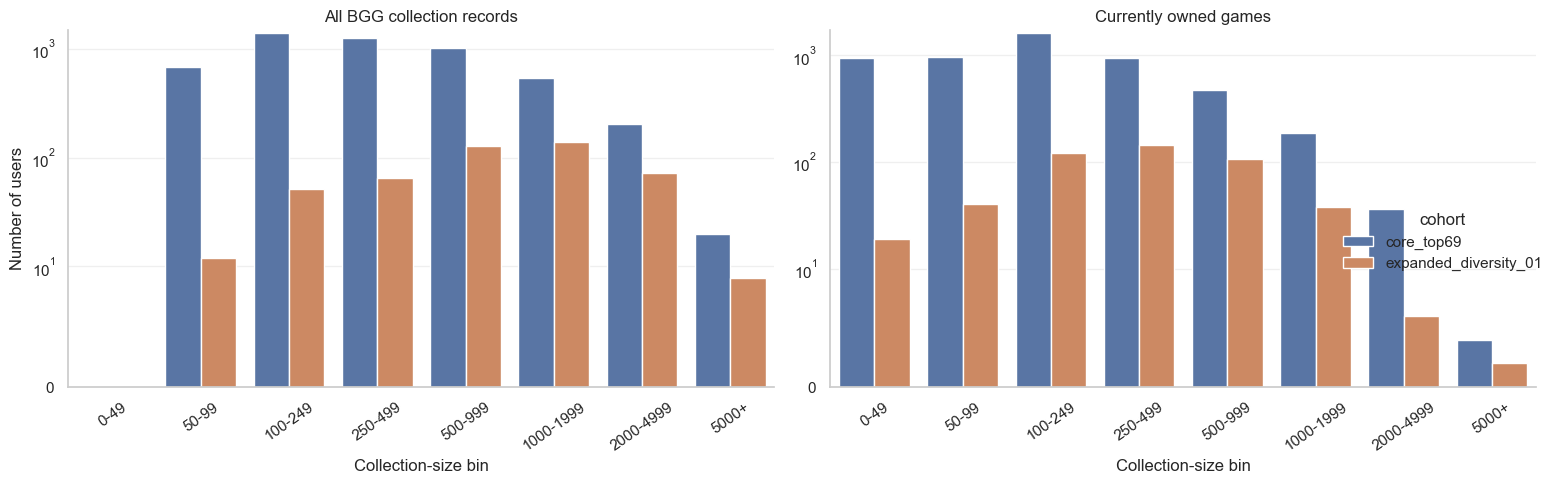

In [30]:
collection_bins = [0, 49, 99, 249, 499, 999, 1999, 4999, np.inf]
collection_labels = ["0-49", "50-99", "100-249", "250-499", "500-999", "1000-1999", "2000-4999", "5000+"]

binned_frames = []
for metric, label in [
    ("collection_item_count", "All BGG collection records"),
    ("owned_count", "Currently owned games"),
]:
    tmp = users[["cohort", metric]].copy()
    tmp["bin"] = pd.cut(tmp[metric], bins=collection_bins, labels=collection_labels, include_lowest=True)
    counts = tmp.groupby(["cohort", "bin"], observed=False).size().reset_index(name="n_users")
    counts["metric"] = label
    binned_frames.append(counts)

collection_bin_counts = pd.concat(binned_frames, ignore_index=True)

g = sns.catplot(
    data=collection_bin_counts,
    x="bin",
    y="n_users",
    hue="cohort",
    col="metric",
    kind="bar",
    height=5,
    aspect=1.35,
    sharey=False,
)
g.set_axis_labels("Collection-size bin", "Number of users")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=35)
    ax.set_yscale("symlog", linthresh=10)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

collection_bin_counts.pivot_table(
    index=["metric", "bin"],
    columns="cohort",
    values="n_users",
    fill_value=0,
    observed=False,
)

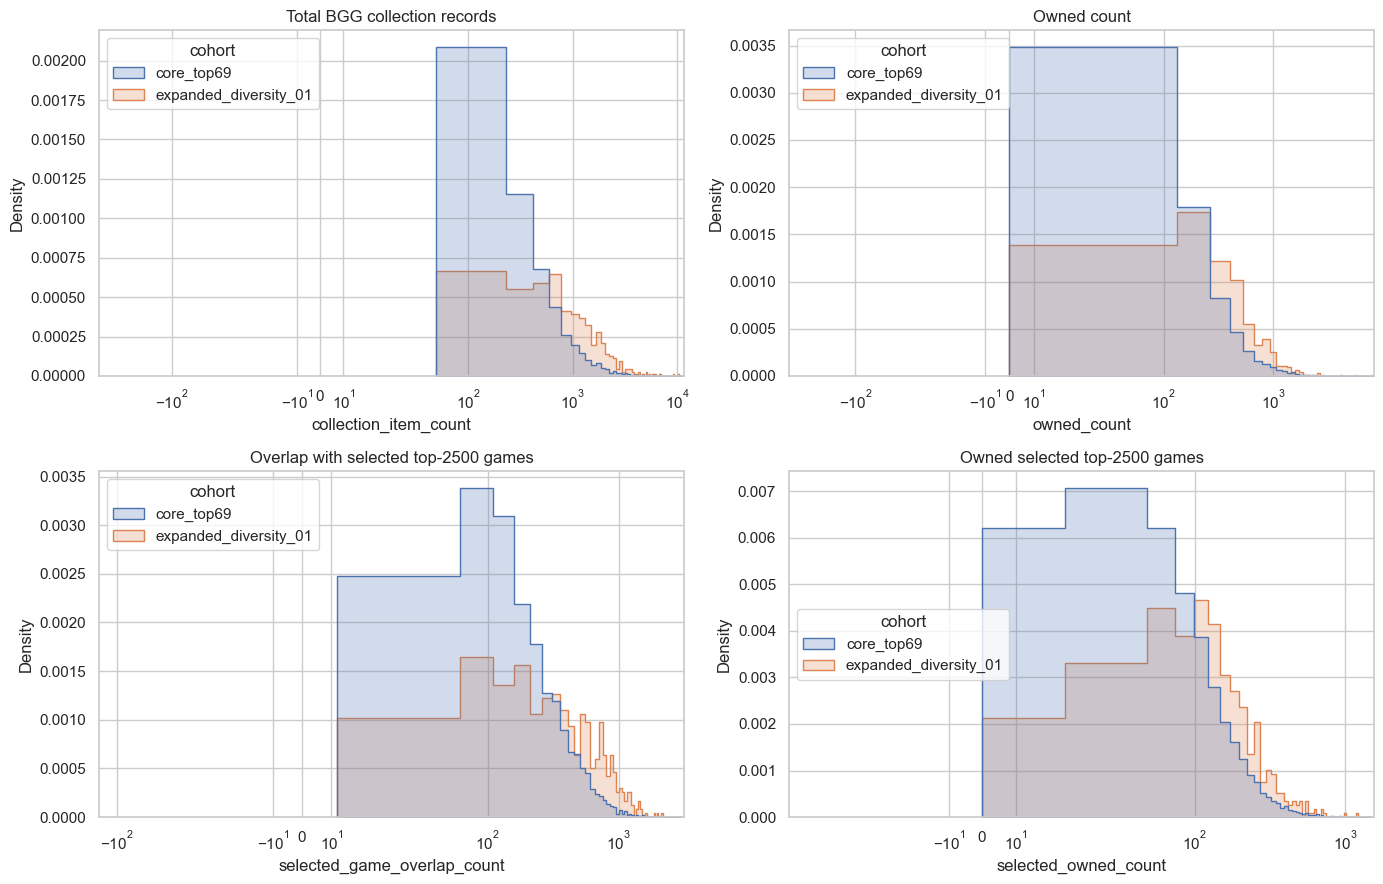

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_specs = [
    ("collection_item_count", "Total BGG collection records"),
    ("owned_count", "Owned count"),
    ("selected_game_overlap_count", "Overlap with selected top-2500 games"),
    ("selected_owned_count", "Owned selected top-2500 games"),
]

for ax, (col, title) in zip(axes.ravel(), plot_specs):
    sns.histplot(data=users, x=col, hue="cohort", bins=60, element="step", stat="density", common_norm=False, ax=ax)
    ax.set_xscale("symlog", linthresh=50)
    ax.set_title(title)
    ax.set_xlabel(col)

plt.tight_layout()

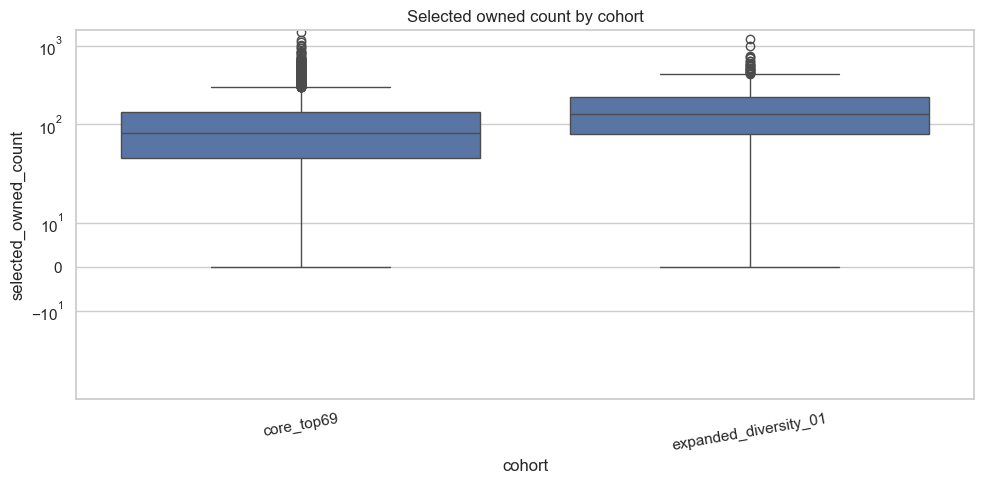

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=users, x="cohort", y="selected_owned_count", ax=ax)
ax.set_yscale("symlog", linthresh=20)
ax.set_title("Selected owned count by cohort")
plt.xticks(rotation=10)
plt.tight_layout()

## Heavy-Collector Influence Diagnostics

For a user with `d` selected owned games, a raw projection would add `d choose 2` pair contributions. This shows why user-normalized/resource-allocation projection may be important.

In [33]:
users["raw_pair_contribution_selected_owned"] = users["selected_owned_count"].fillna(0).astype(int).map(lambda d: d * (d - 1) // 2)

cols = ["username", "cohort", "collection_item_count", "owned_count", "selected_owned_count", "raw_pair_contribution_selected_owned"]
users.sort_values("raw_pair_contribution_selected_owned", ascending=False)[cols].head(20)

,username,cohort,collection_item_count,owned_count,selected_owned_count,raw_pair_contribution_selected_owned
58,Viniciuszen,core_top69,3853,2866,1481,1095940
5453,jmdsplotter,expanded_diversity_01,9275,8024,1201,720600
341,DeviantMagick,core_top69,6797,5532,1164,676866
4125,Blipman,core_top69,4811,4767,1121,627760
2151,dziadekjoe,core_top69,6726,2278,1026,525825
5183,Got1000,expanded_diversity_01,1001,1001,999,498501
4093,Benjaminviking,core_top69,4299,3024,979,478731
54,Boltana,core_top69,5933,5305,932,433846
1418,quetzalt,core_top69,3055,2842,926,428275
881,Pozman,core_top69,6679,3986,863,371953


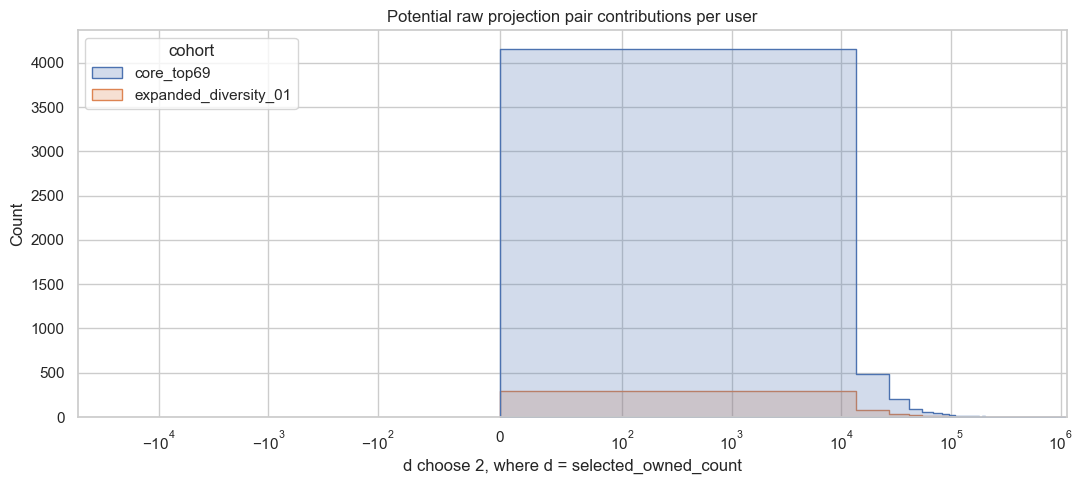

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(data=users, x="raw_pair_contribution_selected_owned", hue="cohort", bins=80, element="step", common_norm=False, ax=ax)
ax.set_xscale("symlog", linthresh=100)
ax.set_title("Potential raw projection pair contributions per user")
ax.set_xlabel("d choose 2, where d = selected_owned_count")
plt.tight_layout()

## Game Metadata Overview

Mechanics and categories will later be node attributes and validation labels, not inputs to the behavioral graph.

In [35]:
def split_pipe(value):
    if pd.isna(value) or value == "":
        return []
    return [part.strip() for part in str(value).split("|") if part.strip()]

details_2500["mechanics_list"] = details_2500["mechanics"].map(split_pipe)
details_2500["categories_list"] = details_2500["categories"].map(split_pipe)
details_2500["n_mechanics"] = details_2500["mechanics_list"].map(len)
details_2500["n_categories"] = details_2500["categories_list"].map(len)

print("unique mechanics:", len(set(x for xs in details_2500["mechanics_list"] for x in xs)))
print("unique categories:", len(set(x for xs in details_2500["categories_list"] for x in xs)))
details_2500[["bgg_id", "name", "overall_rank", "average_rating", "average_weight", "n_mechanics", "n_categories", "mechanics", "categories"]].head(10)

unique mechanics: 191
unique categories: 85


,bgg_id,name,overall_rank,average_rating,average_weight,n_mechanics,n_categories,mechanics,categories
0,224517,Brass: Birmingham,1,8.56572,3.8632,14,6,Chaining | End Game Bonuses | Hand Management ...,Age of Reason | Economic | Industry / Manufact...
1,342942,Ark Nova,2,8.54109,3.7975,17,3,Contracts | End Game Bonuses | Events | Grid C...,Animals | Card Game | Environmental
2,161936,Pandemic Legacy: Season 1,3,8.50433,2.8278,11,2,Action Points | Cooperative Game | Hand Manage...,Environmental | Medical
3,174430,Gloomhaven,4,8.54120,3.9179,24,5,Action Queue | Action Retrieval | Campaign / B...,Adventure | Exploration | Fantasy | Fighting |...
4,397598,Dune: Imperium – Uprising,5,8.70166,3.5241,14,3,Automatic Resource Growth | Card Play Conflict...,Movies / TV / Radio theme | Novel-based | Scie...
5,316554,Dune: Imperium,6,8.41393,3.0762,15,4,"Card Play Conflict Resolution | Deck, Bag, and...",Movies / TV / Radio theme | Novel-based | Poli...
6,233078,Twilight Imperium: Fourth Edition,7,8.56498,4.3501,17,9,Action Drafting | Area-Impulse | Dice Rolling ...,Civilization | Economic | Exploration | Negoti...
7,115746,War of the Ring: Second Edition,8,8.55240,4.2231,11,5,Area Majority / Influence | Area Movement | Ca...,Fantasy | Fighting | Novel-based | Territory B...
8,167791,Terraforming Mars,9,8.33884,3.2704,13,7,Closed Drafting | Contracts | End Game Bonuses...,Civilization | Economic | Environmental | Indu...
9,187645,Star Wars: Rebellion,10,8.42252,3.7530,18,5,Area Majority / Influence | Area Movement | Ca...,Civil War | Movies / TV / Radio theme | Scienc...


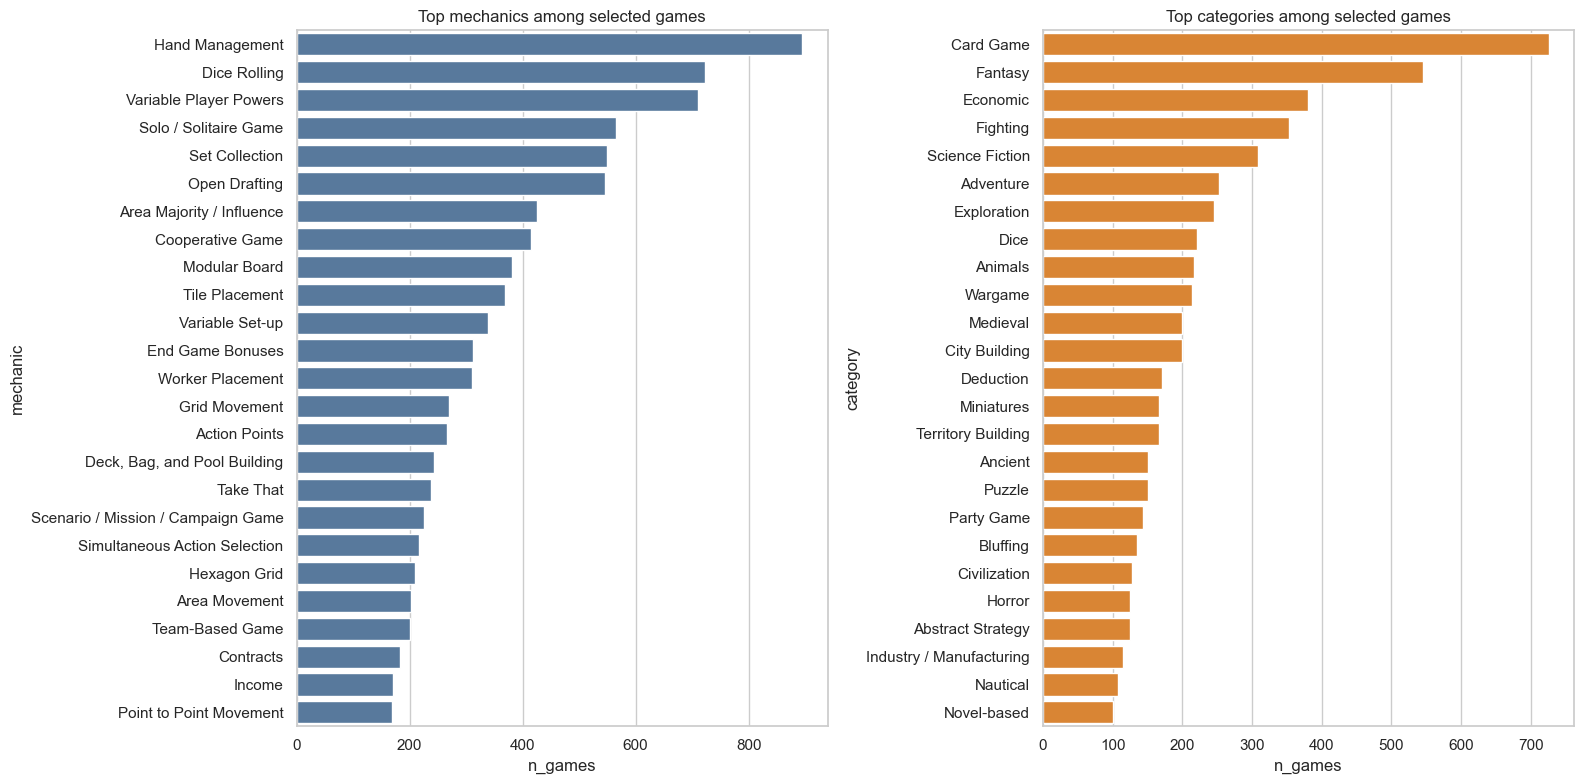

In [36]:
from collections import Counter

mechanic_counts = Counter(x for xs in details_2500["mechanics_list"] for x in xs)
category_counts = Counter(x for xs in details_2500["categories_list"] for x in xs)

top_mech = pd.DataFrame(mechanic_counts.most_common(25), columns=["mechanic", "n_games"])
top_cat = pd.DataFrame(category_counts.most_common(25), columns=["category", "n_games"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=top_mech, y="mechanic", x="n_games", ax=axes[0], color="#4c78a8")
axes[0].set_title("Top mechanics among selected games")
sns.barplot(data=top_cat, y="category", x="n_games", ax=axes[1], color="#f58518")
axes[1].set_title("Top categories among selected games")
plt.tight_layout()

## Chunked Edge Readers

The baseline edge file is large, so the helpers below stream only the needed columns.

In [37]:
BASE_EDGE_CSV = BASE_DIR / "reliable_user_collection_edges.csv"
EXP_EDGE_CSV = EXP_DIR / "reliable_user_collection_edges.csv"

def iter_edge_chunks(edge_csv, usecols=None, chunksize=500_000):
    return pd.read_csv(edge_csv, usecols=usecols, chunksize=chunksize, low_memory=False)

def load_game_user_sets(edge_paths, game_ids, owned_only=True, chunksize=500_000):
    game_ids = set(int(x) for x in game_ids)
    users_by_game = {gid: set() for gid in game_ids}
    usecols = ["username", "bgg_id", "own"]
    for edge_csv in edge_paths:
        for chunk in iter_edge_chunks(edge_csv, usecols=usecols, chunksize=chunksize):
            chunk = chunk[chunk["bgg_id"].isin(game_ids)]
            if owned_only:
                chunk = chunk[chunk["own"].fillna(0).astype(int) == 1]
            for gid, group in chunk.groupby("bgg_id"):
                users_by_game[int(gid)].update(group["username"].dropna().astype(str))
    return users_by_game

def similarity_matrices(users_by_game, game_ids):
    game_ids = list(map(int, game_ids))
    n = len(game_ids)
    co = np.zeros((n, n), dtype=int)
    cosine = np.zeros((n, n), dtype=float)
    jaccard = np.zeros((n, n), dtype=float)
    sizes = np.array([len(users_by_game[gid]) for gid in game_ids], dtype=float)
    for a in range(n):
        set_a = users_by_game[game_ids[a]]
        for b in range(a, n):
            set_b = users_by_game[game_ids[b]]
            inter = len(set_a & set_b)
            union = len(set_a | set_b)
            co[a, b] = co[b, a] = inter
            if sizes[a] and sizes[b]:
                cosine[a, b] = cosine[b, a] = inter / math.sqrt(sizes[a] * sizes[b])
            if union:
                jaccard[a, b] = jaccard[b, a] = inter / union
    return co, cosine, jaccard, sizes

## Co-Ownership For The First / Top 100 Games

This streams the edge files and may take a little while. Set `EDGE_SCOPE` to `baseline` or `merged`.

In [38]:
EDGE_SCOPE = "merged"  # options: "baseline", "merged"
N_TOP_GAMES = 100

top_games = details_2500.sort_values("overall_rank").head(N_TOP_GAMES).copy()
top_game_ids = top_games["bgg_id"].astype(int).tolist()
id_to_name = dict(zip(top_games["bgg_id"].astype(int), top_games["name"]))

edge_paths = [BASE_EDGE_CSV] if EDGE_SCOPE == "baseline" else [BASE_EDGE_CSV, EXP_EDGE_CSV]
users_by_top_game = load_game_user_sets(edge_paths, top_game_ids, owned_only=True)
co_mat, cos_mat, jac_mat, owner_sizes = similarity_matrices(users_by_top_game, top_game_ids)

print("scope:", EDGE_SCOPE)
print("top games:", len(top_game_ids))
print("owner count range:", int(owner_sizes.min()), int(owner_sizes.max()))

scope: merged
top games: 100
owner count range: 196 2275


In [39]:
owner_counts_top100 = pd.DataFrame({
    "bgg_id": top_game_ids,
    "name": [id_to_name[x] for x in top_game_ids],
    "rank": top_games["overall_rank"].astype(int).tolist(),
    "owner_count_in_scope": owner_sizes.astype(int),
})
owner_counts_top100.sort_values("owner_count_in_scope", ascending=False).head(20)

,bgg_id,name,rank,owner_count_in_scope
23,173346,7 Wonders Duel,24,2275
8,167791,Terraforming Mars,9,2251
95,230802,Azul,96,2218
37,266192,Wingspan,38,2129
1,342942,Ark Nova,2,1861
25,169786,Scythe,26,1799
0,224517,Brass: Birmingham,1,1774
29,312484,Lost Ruins of Arnak,30,1639
59,295947,Cascadia,60,1569
10,162886,Spirit Island,11,1554


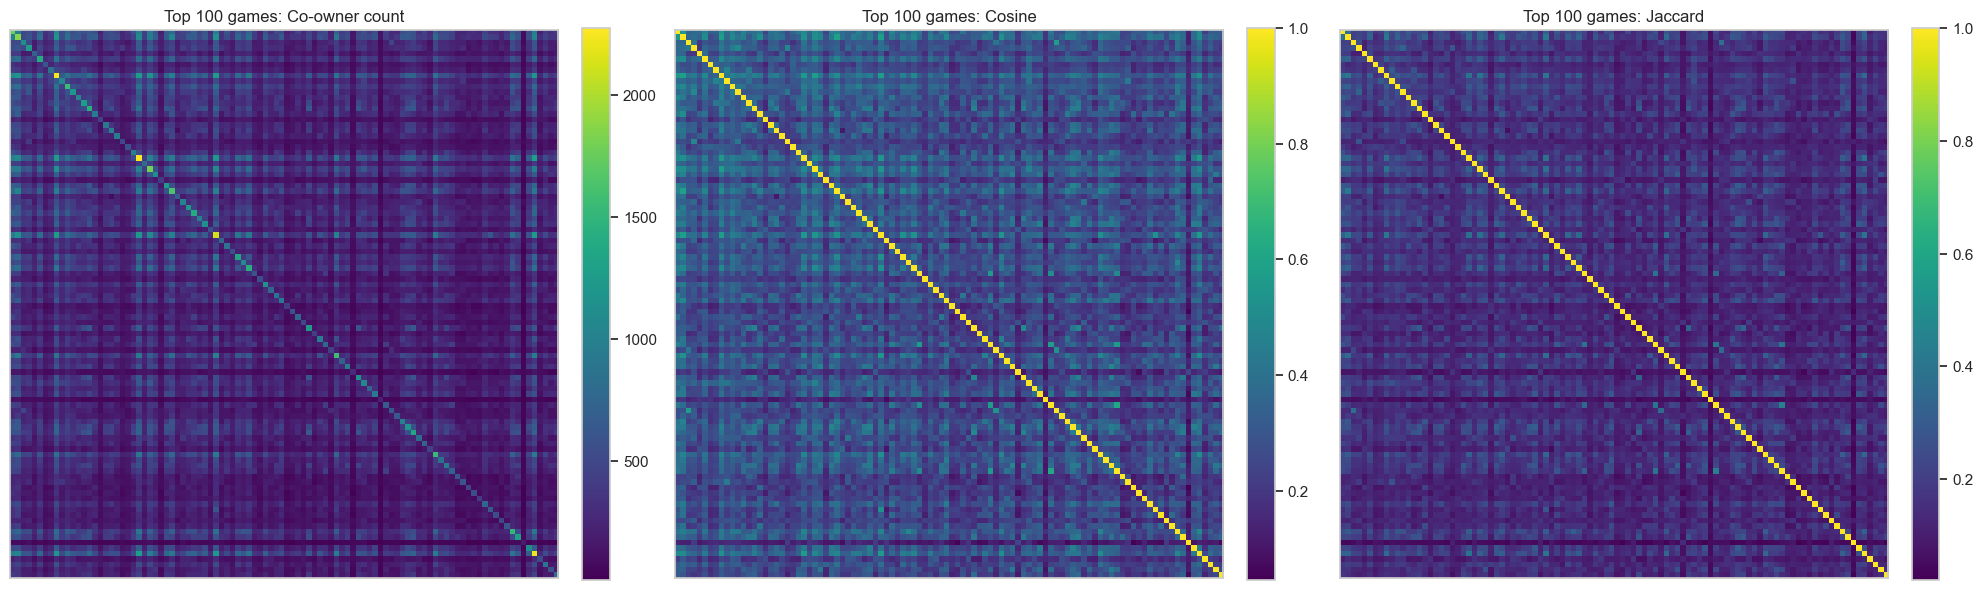

In [40]:
labels = [f"{int(r)}. {name[:18]}" for r, name in zip(top_games["overall_rank"], top_games["name"])]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, mat, title in zip(axes, [co_mat, cos_mat, jac_mat], ["Co-owner count", "Cosine", "Jaccard"]):
    im = ax.imshow(mat, cmap="viridis")
    ax.set_title(f"Top {N_TOP_GAMES} games: {title}")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

In [41]:
pairs = []
for i, j in combinations(range(len(top_game_ids)), 2):
    gid_i = top_game_ids[i]
    gid_j = top_game_ids[j]
    pairs.append({
        "game_i": id_to_name[gid_i],
        "game_j": id_to_name[gid_j],
        "co_owners": co_mat[i, j],
        "cosine": cos_mat[i, j],
        "jaccard": jac_mat[i, j],
    })

pair_df = pd.DataFrame(pairs)
pair_df.sort_values("cosine", ascending=False).head(30)

,game_i,game_j,co_owners,cosine,jaccard
4465,Lisboa,The Gallerist,433,0.619603,0.448240
126,Ark Nova,Lost Ruins of Arnak,1036,0.593194,0.420455
105,Ark Nova,Terraforming Mars,1199,0.585812,0.411603
134,Ark Nova,Wingspan,1162,0.583774,0.410891
780,Terraforming Mars,Scythe,1161,0.576938,0.401869
263,Pandemic Legacy: Season 1,Pandemic Legacy: Season 2,486,0.576617,0.381476
792,Terraforming Mars,Wingspan,1262,0.576479,0.404747
4057,On Mars,Lisboa,412,0.575157,0.402344
3422,Kanban EV,On Mars,391,0.574937,0.399387
2095,7 Wonders Duel,Azul,1290,0.574273,0.402747


## First 100 Games As A Small Network

This is not the final project graph. It is just a visual intuition tool for co-ownership relationships among the first 100 ranked games.

In [42]:
import networkx as nx

TOP_K_FOR_VIS = 5
G = nx.Graph()
for idx, gid in enumerate(top_game_ids):
    G.add_node(gid, name=id_to_name[gid], rank=int(top_games.iloc[idx]["overall_rank"]))

for i, gid_i in enumerate(top_game_ids):
    neighbors = np.argsort(cos_mat[i])[::-1]
    kept = 0
    for j in neighbors:
        if i == j or cos_mat[i, j] <= 0:
            continue
        gid_j = top_game_ids[j]
        G.add_edge(gid_i, gid_j, weight=float(cos_mat[i, j]), co_owners=int(co_mat[i, j]))
        kept += 1
        if kept >= TOP_K_FOR_VIS:
            break

print("nodes", G.number_of_nodes(), "edges", G.number_of_edges())
print("components", nx.number_connected_components(G))

nodes 100 edges 424
components 1


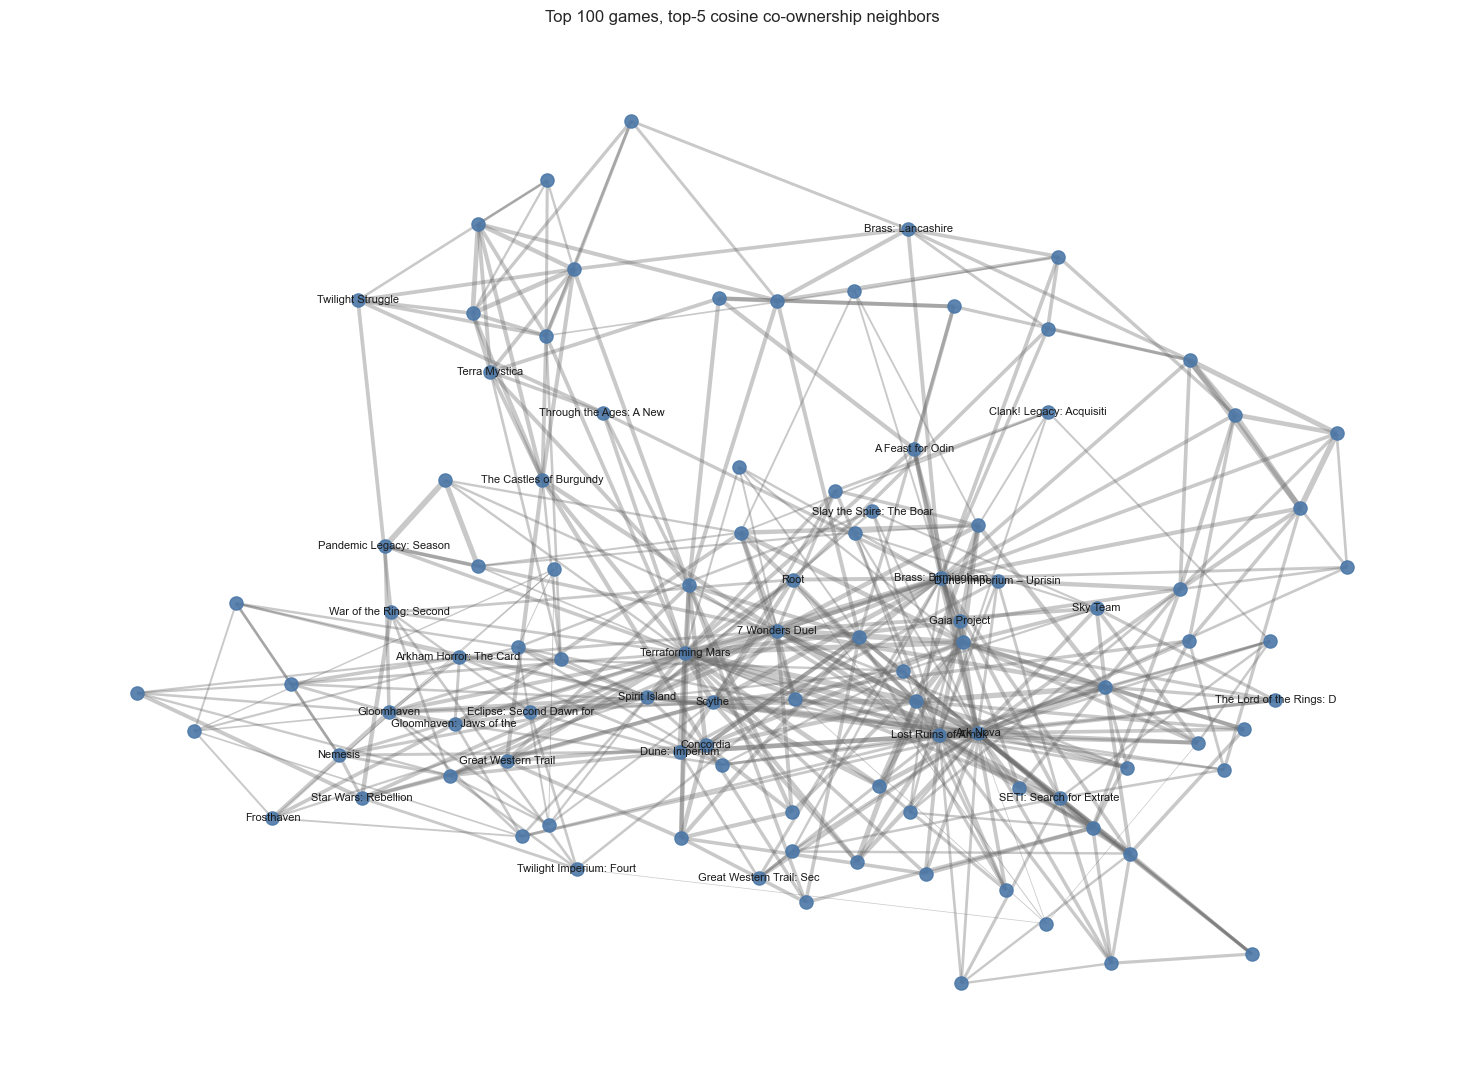

In [43]:
plt.figure(figsize=(15, 11))
pos = nx.spring_layout(G, seed=42, weight="weight", k=0.35)
weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
widths = 0.5 + 4 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)

nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35, edge_color="#666666")
nx.draw_networkx_nodes(G, pos, node_size=90, node_color="#4c78a8", alpha=0.9)

label_nodes = sorted(G.nodes(), key=lambda gid: G.nodes[gid]["rank"])[:35]
labels_small = {gid: G.nodes[gid]["name"][:24] for gid in label_nodes}
nx.draw_networkx_labels(G, pos, labels=labels_small, font_size=8)

plt.title(f"Top {N_TOP_GAMES} games, top-{TOP_K_FOR_VIS} cosine co-ownership neighbors")
plt.axis("off")
plt.tight_layout()

## Rating Signal EDA

Ratings are useful as a secondary behavioral layer. This section checks availability and simple distributions without building the final rating graph.

In [44]:
def load_rating_sample(edge_paths, game_ids=None, max_rows=None, chunksize=500_000):
    frames = []
    usecols = ["username", "bgg_id", "user_rating", "own", "numplays"]
    game_ids = None if game_ids is None else set(map(int, game_ids))
    total = 0
    for edge_csv in edge_paths:
        for chunk in iter_edge_chunks(edge_csv, usecols=usecols, chunksize=chunksize):
            if game_ids is not None:
                chunk = chunk[chunk["bgg_id"].isin(game_ids)]
            chunk["user_rating"] = pd.to_numeric(chunk["user_rating"], errors="coerce")
            chunk = chunk[chunk["user_rating"].notna()]
            if not chunk.empty:
                frames.append(chunk)
                total += len(chunk)
            if max_rows is not None and total >= max_rows:
                return pd.concat(frames, ignore_index=True).head(max_rows)
    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame(columns=usecols)

rating_top100 = load_rating_sample(edge_paths, game_ids=top_game_ids)
print("rating rows for top 100 games:", len(rating_top100))
rating_top100.head()

rating rows for top 100 games: 160293


,username,bgg_id,own,user_rating,numplays
0,Eternal_BB,167791,1,9.0,12
1,Eternal_BB,173346,1,10.0,9
2,Eternal_BB,182874,1,7.3,3
3,Eternal_BB,295947,1,8.5,8
4,Eternal_BB,312484,1,8.5,21


,bgg_id,n_ratings,name
27,167791,3542,Terraforming Mars
65,266192,3357,Wingspan
52,230802,3251,Azul
30,173346,3233,7 Wonders Duel
28,169786,3176,Scythe
10,84876,2861,The Castles of Burgundy
51,224517,2694,Brass: Birmingham
86,342942,2669,Ark Nova
7,31260,2566,Agricola
55,237182,2530,Root


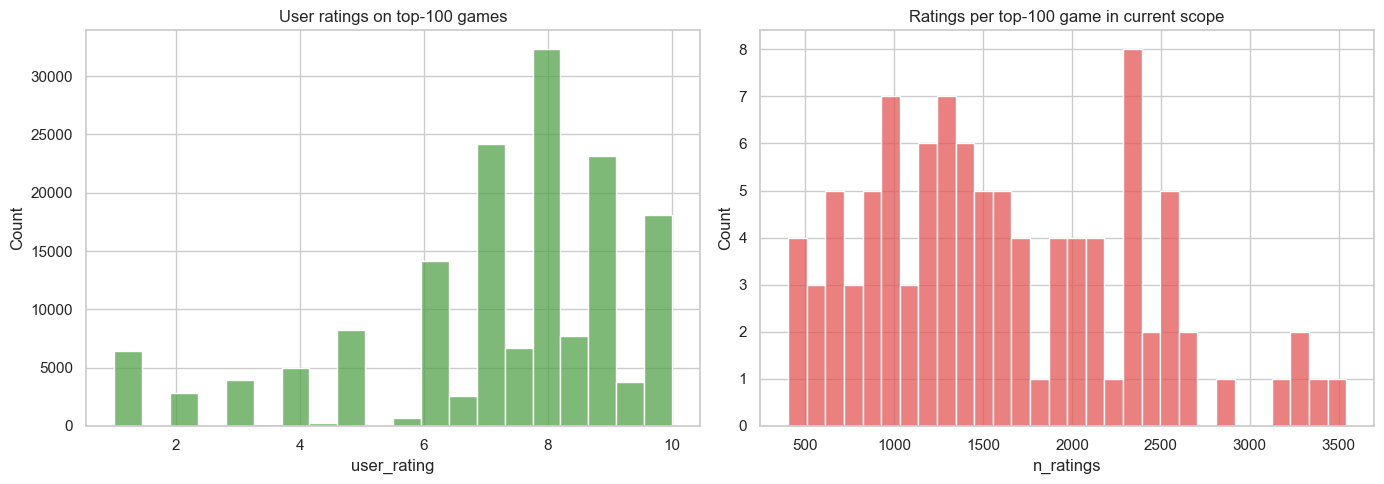

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rating_top100["user_rating"], bins=20, ax=axes[0], color="#54a24b")
axes[0].set_title("User ratings on top-100 games")
axes[0].set_xlabel("user_rating")

rating_counts = rating_top100.groupby("bgg_id").size().rename("n_ratings").reset_index()
rating_counts["name"] = rating_counts["bgg_id"].map(id_to_name)
sns.histplot(rating_counts["n_ratings"], bins=30, ax=axes[1], color="#e45756")
axes[1].set_title("Ratings per top-100 game in current scope")
axes[1].set_xlabel("n_ratings")
plt.tight_layout()

rating_counts.sort_values("n_ratings", ascending=False).head(20)

## All-2500 Per-Game Representation

This section streams the baseline and expansion edge files and counts how many reliable users own each selected game. This game-side degree distribution is one of the most important diagnostics for projection design.

In [46]:
def count_game_owners(edge_paths, game_ids, chunksize=500_000):
    game_ids = set(map(int, game_ids))
    owner_sets = {gid: set() for gid in game_ids}
    usecols = ["username", "bgg_id", "own"]
    for edge_csv in edge_paths:
        print("streaming", edge_csv.name)
        for chunk in pd.read_csv(edge_csv, usecols=usecols, chunksize=chunksize, low_memory=False):
            chunk = chunk[chunk["bgg_id"].isin(game_ids)]
            chunk = chunk[chunk["own"].fillna(0).astype(int) == 1]
            if chunk.empty:
                continue
            for gid, group in chunk.groupby("bgg_id"):
                owner_sets[int(gid)].update(group["username"].dropna().astype(str))
    return pd.DataFrame({
        "bgg_id": list(owner_sets.keys()),
        "n_owners": [len(v) for v in owner_sets.values()],
    })

baseline_game_owners = count_game_owners([BASE_EDGE_CSV], selected_ids)
merged_game_owners = count_game_owners([BASE_EDGE_CSV, EXP_EDGE_CSV], selected_ids)

game_coverage = (
    details_2500[["bgg_id", "name", "overall_rank", "average_rating", "average_weight", "owned", "users_rated"]]
    .merge(baseline_game_owners.rename(columns={"n_owners": "baseline_owners"}), on="bgg_id", how="left")
    .merge(merged_game_owners.rename(columns={"n_owners": "merged_owners"}), on="bgg_id", how="left")
)
game_coverage[["baseline_owners", "merged_owners"]] = game_coverage[["baseline_owners", "merged_owners"]].fillna(0).astype(int)
game_coverage["expansion_added_owners"] = game_coverage["merged_owners"] - game_coverage["baseline_owners"]
game_coverage["baseline_owner_rate"] = game_coverage["baseline_owners"] / len(baseline_users)
game_coverage["merged_owner_rate"] = game_coverage["merged_owners"] / len(users)
game_coverage["owner_rate_delta"] = game_coverage["merged_owner_rate"] - game_coverage["baseline_owner_rate"]

game_coverage[["baseline_owners", "merged_owners", "expansion_added_owners", "owner_rate_delta"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

streaming reliable_user_collection_edges.csv
streaming reliable_user_collection_edges.csv
streaming reliable_user_collection_edges.csv


,baseline_owners,merged_owners,expansion_added_owners,owner_rate_delta
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,224.025200,255.952400,31.927200,0.001987
std,241.553343,267.545485,27.758785,0.001916
min,18.000000,24.000000,2.000000,-0.004467
10%,65.000000,77.000000,9.000000,0.000106
25%,89.750000,105.000000,14.000000,0.000665
50%,139.000000,162.000000,24.000000,0.001578
75%,254.000000,295.000000,40.000000,0.002868
90%,491.100000,560.000000,63.100000,0.004477
95%,685.250000,766.050000,88.000000,0.005681


,overall_rank,bgg_id,name,baseline_owners,merged_owners,expansion_added_owners
23,24,173346,7 Wonders Duel,2077,2275,198
8,9,167791,Terraforming Mars,2053,2251,198
95,96,230802,Azul,1990,2218,228
238,239,822,Carcassonne,1920,2133,213
37,38,266192,Wingspan,1938,2129,191
160,161,178900,Codenames,1874,2093,219
169,170,30549,Pandemic,1772,1948,176
614,615,13,Catan,1726,1918,192
145,146,163412,Patchwork,1672,1861,189
1,2,342942,Ark Nova,1690,1861,171


,overall_rank,bgg_id,name,baseline_owners,merged_owners,expansion_added_owners
1753,1754,30618,Eat Poop You Cat,18,24,6
2495,2496,108018,Riichi Mahjong,20,25,5
2155,2156,2251,Strat-O-Matic Baseball,26,29,3
2086,2087,131111,Codex: Card-Time Strategy – Deluxe Set,26,30,4
2497,2498,65564,Hornet Leader: Carrier Air Operations,24,31,7
1973,1974,3072,Necromunda,30,32,2
2490,2491,304847,Hidden Games Crime Scene: The New Haven Case,30,33,3
2138,2139,3565,Mordheim: City of the Damned,29,33,4
2228,2229,240271,Core Space,31,35,4
2469,2470,343322,EXIT: The Game – Advent Calendar: The Hunt for...,34,37,3


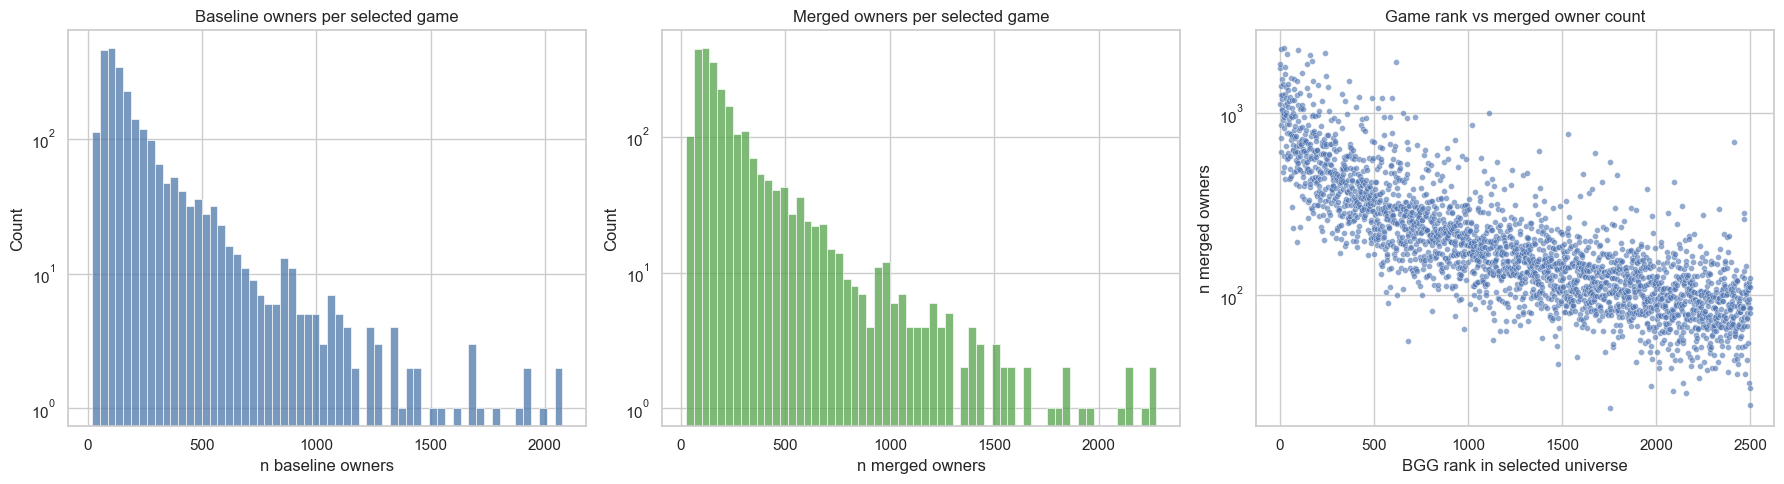

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(game_coverage["baseline_owners"], bins=60, ax=axes[0], color="#4c78a8")
axes[0].set_title("Baseline owners per selected game")
axes[0].set_xlabel("n baseline owners")
axes[0].set_yscale("log")

sns.histplot(game_coverage["merged_owners"], bins=60, ax=axes[1], color="#54a24b")
axes[1].set_title("Merged owners per selected game")
axes[1].set_xlabel("n merged owners")
axes[1].set_yscale("log")

sns.scatterplot(data=game_coverage, x="overall_rank", y="merged_owners", ax=axes[2], s=18, alpha=0.6)
axes[2].set_title("Game rank vs merged owner count")
axes[2].set_xlabel("BGG rank in selected universe")
axes[2].set_ylabel("n merged owners")
axes[2].set_yscale("log")

plt.tight_layout()

display(game_coverage.sort_values("merged_owners", ascending=False).head(20)[["overall_rank", "bgg_id", "name", "baseline_owners", "merged_owners", "expansion_added_owners"]])
display(game_coverage.sort_values("merged_owners", ascending=True).head(20)[["overall_rank", "bgg_id", "name", "baseline_owners", "merged_owners", "expansion_added_owners"]])

## Existing Taxonomy Coverage Reports

These CSVs were already produced by `scripts/analyze_taxonomy_coverage.py`. They show how many reliable baseline users touch each mechanic/category through at least one selected game.

,mechanic,n_games_with_tag_in_universe,n_games_touched,n_distinct_users,user_coverage_ratio,n_edges,n_own_edges,users_per_game
0,Impulse Movement,1,1,86,0.0166,86,51,86.0
1,Crayon Rail System,2,2,205,0.0396,279,99,102.5
2,Induction,2,2,566,0.1094,633,257,283.0
3,Action Timer,3,3,582,0.1125,746,297,194.0
4,Measurement Movement,6,6,879,0.1699,1101,395,146.5


,category,n_games_with_tag_in_universe,n_games_touched,n_distinct_users,user_coverage_ratio,n_edges,n_own_edges,users_per_game
0,Fan Expansion,1,1,98,0.0189,98,62,98.0
1,Third-party Expansion,1,1,98,0.0189,98,62,98.0
2,Korean War,1,1,125,0.0242,130,54,125.0
3,Game System,1,1,185,0.0357,185,70,185.0
4,Expansion for Base-game,2,2,340,0.0657,353,125,170.0


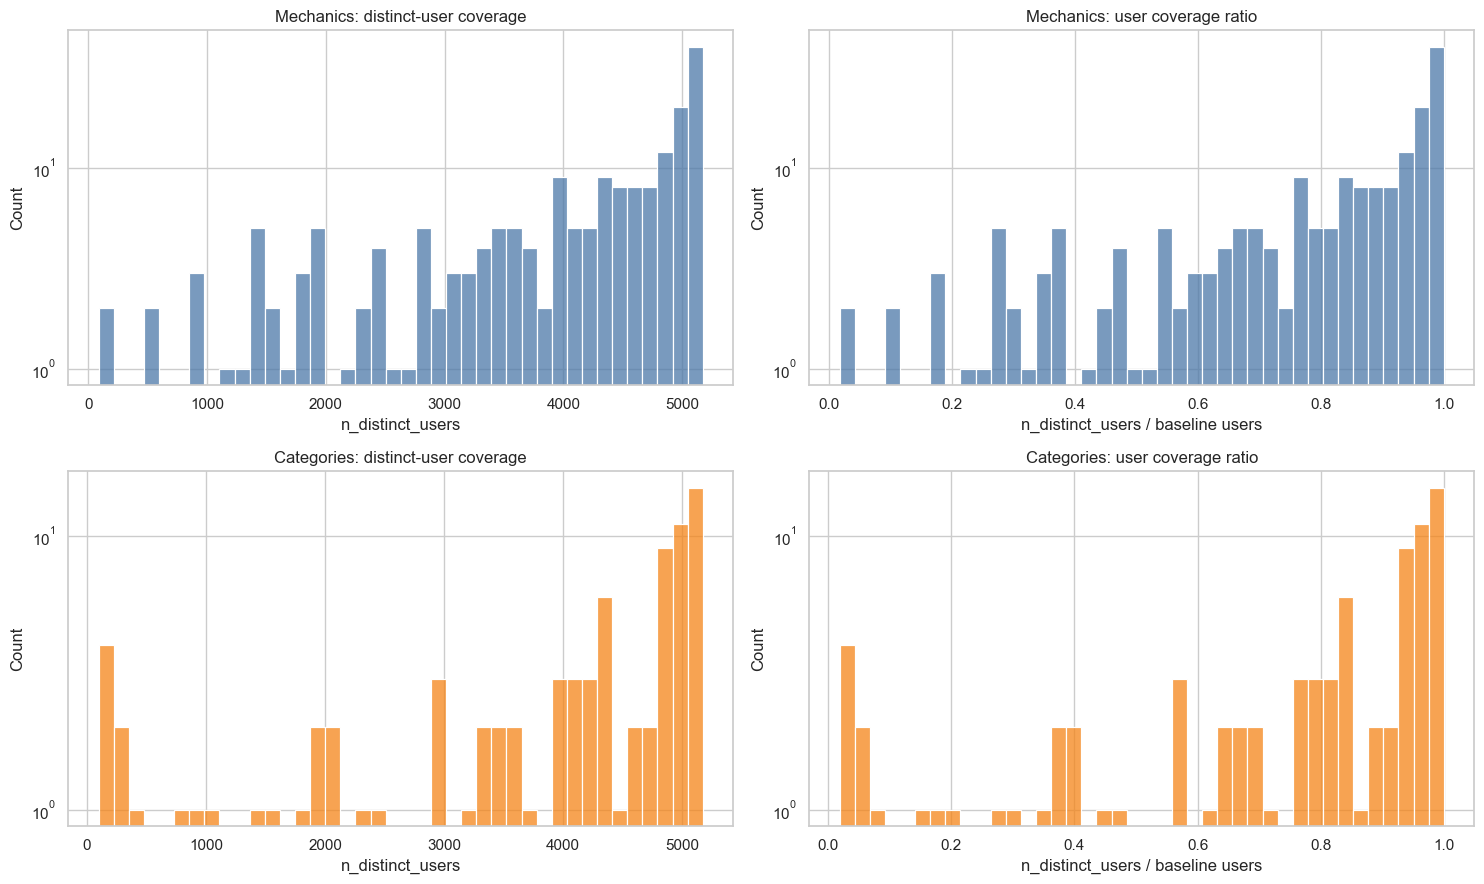

In [48]:
taxonomy_mechanics = pd.read_csv(BASE_DIR / "taxonomy_coverage_mechanics.csv")
taxonomy_categories = pd.read_csv(BASE_DIR / "taxonomy_coverage_categories.csv")

display(taxonomy_mechanics.head())
display(taxonomy_categories.head())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for row_idx, (df, label, color) in enumerate([
    (taxonomy_mechanics, "Mechanics", "#4c78a8"),
    (taxonomy_categories, "Categories", "#f58518"),
]):
    sns.histplot(df["n_distinct_users"], bins=40, ax=axes[row_idx, 0], color=color)
    axes[row_idx, 0].set_title(f"{label}: distinct-user coverage")
    axes[row_idx, 0].set_xlabel("n_distinct_users")
    axes[row_idx, 0].set_yscale("log")

    sns.histplot(df["user_coverage_ratio"], bins=40, ax=axes[row_idx, 1], color=color)
    axes[row_idx, 1].set_title(f"{label}: user coverage ratio")
    axes[row_idx, 1].set_xlabel("n_distinct_users / baseline users")
    axes[row_idx, 1].set_yscale("log")

plt.tight_layout()

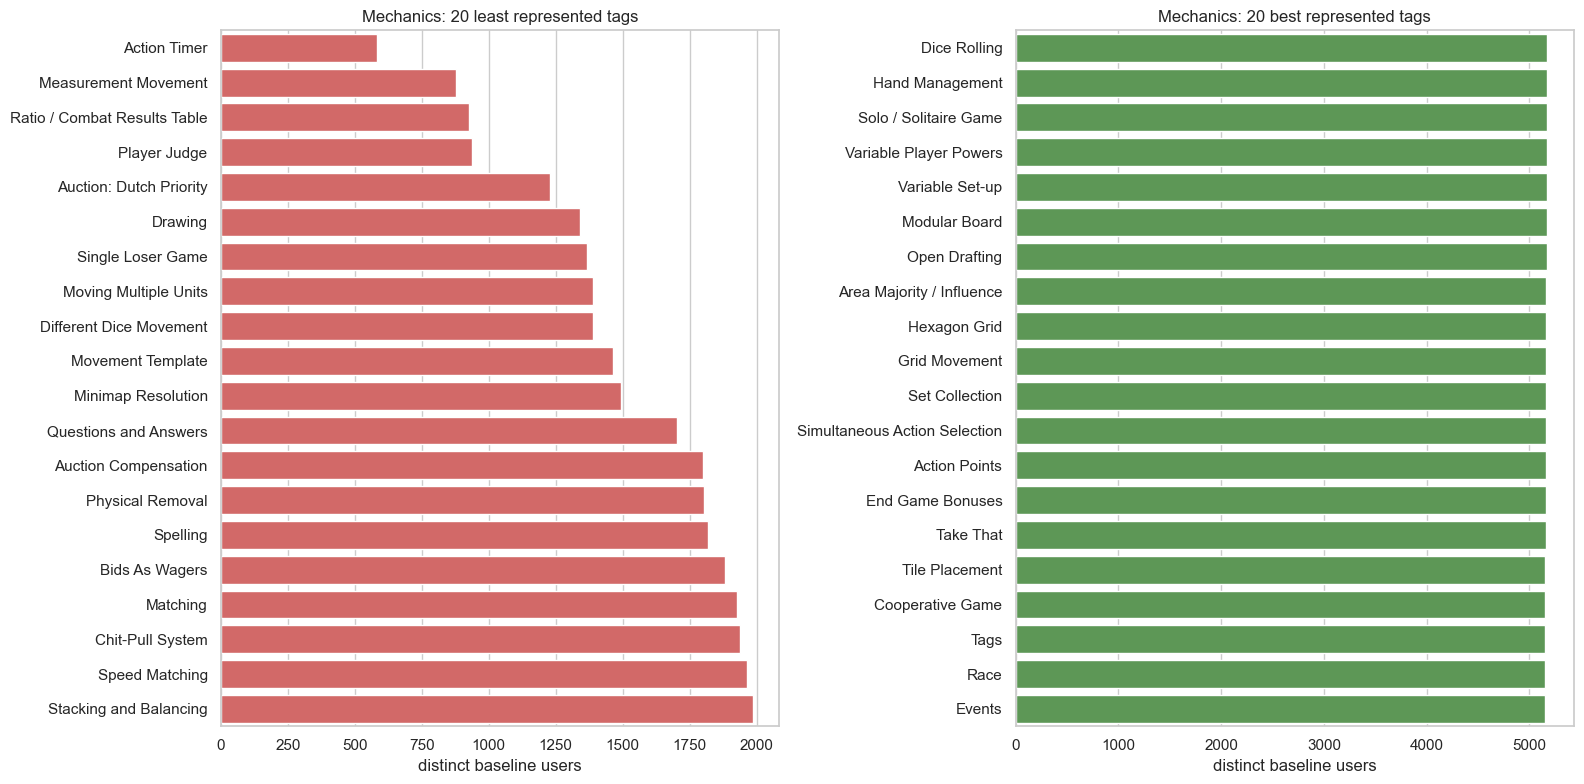

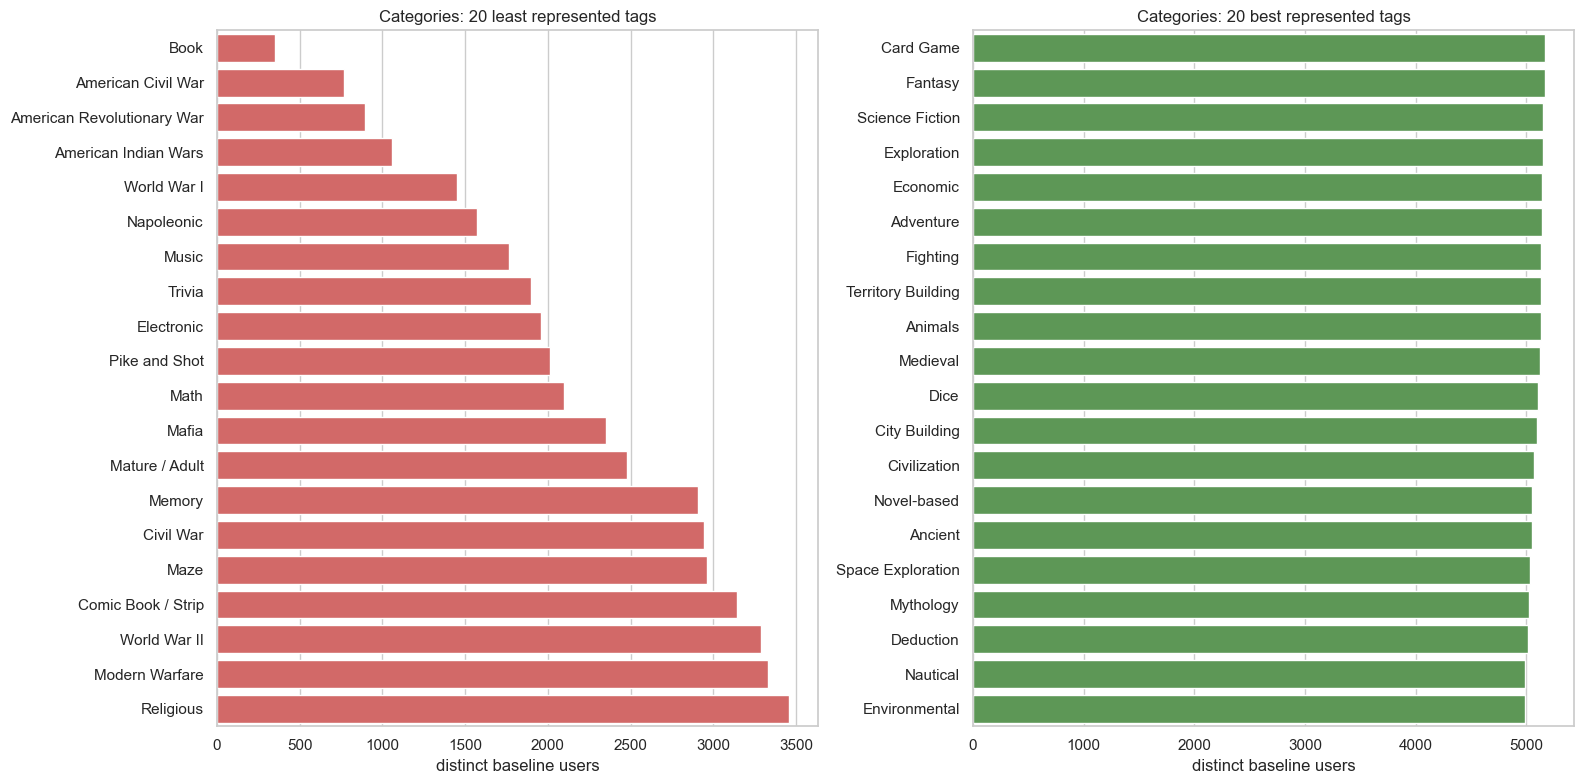

In [49]:
def plot_taxonomy_extremes(df, tag_col, title_prefix, min_games=3):
    d = df[df["n_games_with_tag_in_universe"] >= min_games].copy()
    bottom = d.sort_values("n_distinct_users", ascending=True).head(20)
    top = d.sort_values("n_distinct_users", ascending=False).head(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    sns.barplot(data=bottom, y=tag_col, x="n_distinct_users", ax=axes[0], color="#e45756")
    axes[0].set_title(f"{title_prefix}: 20 least represented tags")
    axes[0].set_xlabel("distinct baseline users")
    axes[0].set_ylabel("")

    sns.barplot(data=top, y=tag_col, x="n_distinct_users", ax=axes[1], color="#54a24b")
    axes[1].set_title(f"{title_prefix}: 20 best represented tags")
    axes[1].set_xlabel("distinct baseline users")
    axes[1].set_ylabel("")

    plt.tight_layout()
    return bottom, top

under_mech, top_mech_coverage = plot_taxonomy_extremes(taxonomy_mechanics, "mechanic", "Mechanics")
under_cat, top_cat_coverage = plot_taxonomy_extremes(taxonomy_categories, "category", "Categories")

## Baseline vs Merged Tag-Coverage Delta

This recomputes ownership-based tag coverage for baseline and merged reliable users. It streams the edge files once per cohort scope and shows which tags gained the most representation after adding the diversity-expansion users.

In [50]:
mech_by_game = dict(zip(details_2500["bgg_id"].astype(int), details_2500["mechanics_list"]))
cat_by_game = dict(zip(details_2500["bgg_id"].astype(int), details_2500["categories_list"]))

def tag_owner_coverage(edge_paths, selected_ids, mech_by_game, cat_by_game, chunksize=500_000):
    selected_ids = set(map(int, selected_ids))
    users_by_mechanic = {tag: set() for tags in mech_by_game.values() for tag in tags}
    users_by_category = {tag: set() for tags in cat_by_game.values() for tag in tags}
    usecols = ["username", "bgg_id", "own"]

    for edge_csv in edge_paths:
        print("streaming", edge_csv.name)
        for chunk in pd.read_csv(edge_csv, usecols=usecols, chunksize=chunksize, low_memory=False):
            chunk = chunk[chunk["bgg_id"].isin(selected_ids)]
            chunk = chunk[chunk["own"].fillna(0).astype(int) == 1]
            if chunk.empty:
                continue
            chunk = chunk[["username", "bgg_id"]].dropna().drop_duplicates()
            for gid, group in chunk.groupby("bgg_id"):
                gid = int(gid)
                user_set = set(group["username"].astype(str))
                for tag in mech_by_game.get(gid, []):
                    users_by_mechanic[tag].update(user_set)
                for tag in cat_by_game.get(gid, []):
                    users_by_category[tag].update(user_set)

    mech = pd.DataFrame({"tag_kind": "mechanic", "tag": list(users_by_mechanic.keys()), "n_owners": [len(v) for v in users_by_mechanic.values()]})
    cat = pd.DataFrame({"tag_kind": "category", "tag": list(users_by_category.keys()), "n_owners": [len(v) for v in users_by_category.values()]})
    return pd.concat([mech, cat], ignore_index=True)

baseline_tag_owners = tag_owner_coverage([BASE_EDGE_CSV], selected_ids, mech_by_game, cat_by_game)
merged_tag_owners = tag_owner_coverage([BASE_EDGE_CSV, EXP_EDGE_CSV], selected_ids, mech_by_game, cat_by_game)

tag_delta = baseline_tag_owners.rename(columns={"n_owners": "baseline_owners"}).merge(
    merged_tag_owners.rename(columns={"n_owners": "merged_owners"}),
    on=["tag_kind", "tag"],
    how="outer",
).fillna(0)
tag_delta[["baseline_owners", "merged_owners"]] = tag_delta[["baseline_owners", "merged_owners"]].astype(int)
tag_delta["added_owners"] = tag_delta["merged_owners"] - tag_delta["baseline_owners"]
tag_delta["baseline_rate"] = tag_delta["baseline_owners"] / len(baseline_users)
tag_delta["merged_rate"] = tag_delta["merged_owners"] / len(users)
tag_delta["rate_delta"] = tag_delta["merged_rate"] - tag_delta["baseline_rate"]
tag_delta["relative_owner_gain"] = np.where(tag_delta["baseline_owners"] > 0, tag_delta["added_owners"] / tag_delta["baseline_owners"], np.nan)

tag_delta.sort_values("relative_owner_gain", ascending=False).head(30)

streaming reliable_user_collection_edges.csv
streaming reliable_user_collection_edges.csv
streaming reliable_user_collection_edges.csv


,tag_kind,tag,baseline_owners,merged_owners,added_owners,baseline_rate,merged_rate,rate_delta,relative_owner_gain
127,mechanic,Crayon Rail System,74,105,31,0.014300,0.018574,0.004275,0.418919
37,category,Korean War,51,67,16,0.009855,0.011852,0.001997,0.313725
33,category,Game System,70,91,21,0.013527,0.016098,0.002571,0.300000
79,category,Vietnam War,205,265,60,0.039614,0.046878,0.007264,0.292683
156,mechanic,Impulse Movement,51,65,14,0.009855,0.011498,0.001643,0.274510
4,category,American Civil War,354,446,92,0.068406,0.078896,0.010490,0.259887
215,mechanic,Ratio / Combat Results Table,492,619,127,0.095072,0.109499,0.014427,0.258130
73,category,Third-party Expansion,62,78,16,0.011981,0.013798,0.001817,0.258065
29,category,Fan Expansion,62,78,16,0.011981,0.013798,0.001817,0.258065
13,category,Book,188,236,48,0.036329,0.041748,0.005419,0.255319


,tag,baseline_owners,merged_owners,added_owners,relative_owner_gain,rate_delta
127,Crayon Rail System,74,105,31,0.418919,0.004275
156,Impulse Movement,51,65,14,0.274510,0.001643
215,Ratio / Combat Results Table,492,619,127,0.258130,0.014427
159,Induction,253,308,55,0.217391,0.005595
235,Single Loser Game,775,918,143,0.184516,0.012633
137,Drawing,682,799,117,0.171554,0.009553
180,Minimap Resolution,750,878,128,0.170667,0.010388
206,Player Judge,505,591,86,0.170297,0.006962
101,Auction: English,727,849,122,0.167813,0.009703
263,Turn Order: Random,1098,1281,183,0.166667,0.014431


,tag,baseline_owners,merged_owners,added_owners,relative_owner_gain,rate_delta
37,Korean War,51,67,16,0.313725,0.001997
33,Game System,70,91,21,0.300000,0.002571
79,Vietnam War,205,265,60,0.292683,0.007264
4,American Civil War,354,446,92,0.259887,0.010490
29,Fan Expansion,62,78,16,0.258065,0.001817
73,Third-party Expansion,62,78,16,0.258065,0.001817
13,Book,188,236,48,0.255319,0.005419
5,American Indian Wars,481,602,121,0.251559,0.013545
6,American Revolutionary War,467,583,116,0.248394,0.012890
51,Napoleonic,768,951,183,0.238281,0.019823


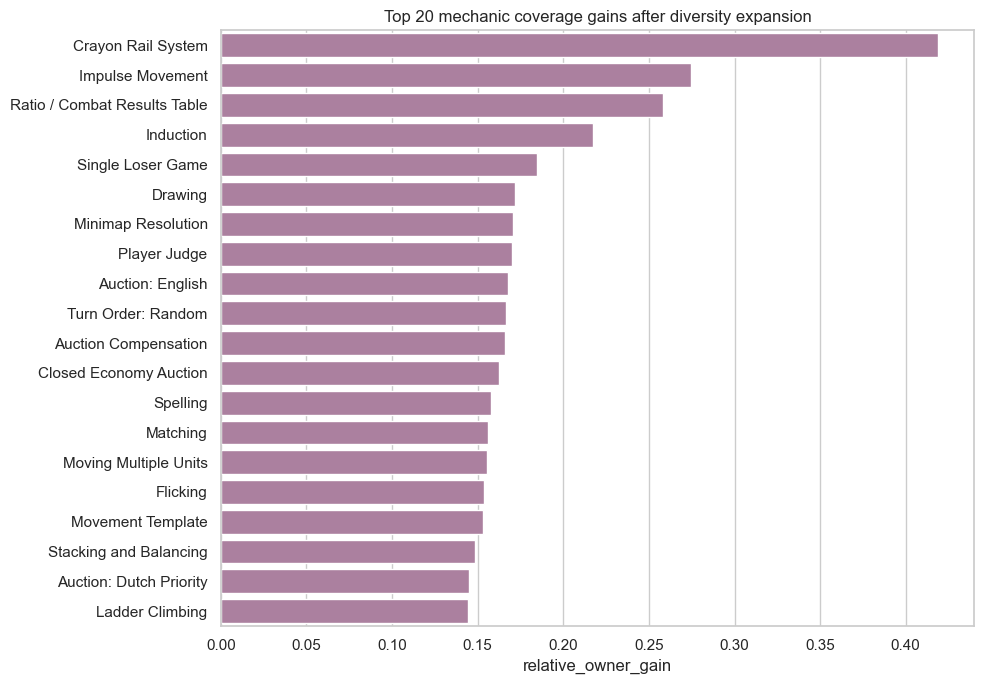

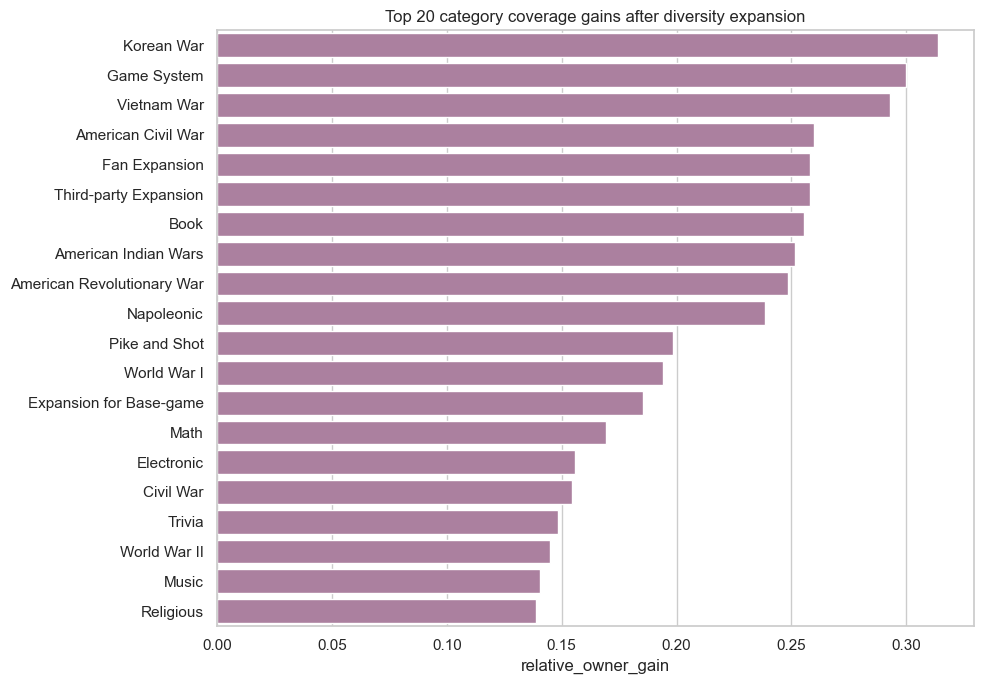

In [51]:
def plot_tag_delta(df, tag_kind, metric="relative_owner_gain", min_baseline_owners=25, n=20):
    d = df[(df["tag_kind"] == tag_kind) & (df["baseline_owners"] >= min_baseline_owners)].copy()
    d = d.sort_values(metric, ascending=False).head(n)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=d, y="tag", x=metric, ax=ax, color="#b279a2")
    ax.set_title(f"Top {n} {tag_kind} coverage gains after diversity expansion")
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    plt.tight_layout()
    return d

top_mechanic_gains = plot_tag_delta(tag_delta, "mechanic")
top_category_gains = plot_tag_delta(tag_delta, "category")

display(top_mechanic_gains[["tag", "baseline_owners", "merged_owners", "added_owners", "relative_owner_gain", "rate_delta"]])
display(top_category_gains[["tag", "baseline_owners", "merged_owners", "added_owners", "relative_owner_gain", "rate_delta"]])

## Multi-Label Complexity Per Game

These histograms show why mechanics/categories should be treated as multi-label node metadata rather than collapsed into one dominant class.

,n_mechanics,n_categories
count,2500.000000,2500.000000
mean,6.264800,3.090000
std,3.284844,1.526444
min,0.000000,0.000000
10%,3.000000,1.000000
25%,4.000000,2.000000
50%,6.000000,3.000000
75%,8.000000,4.000000
90%,11.000000,5.000000
95%,13.000000,6.000000


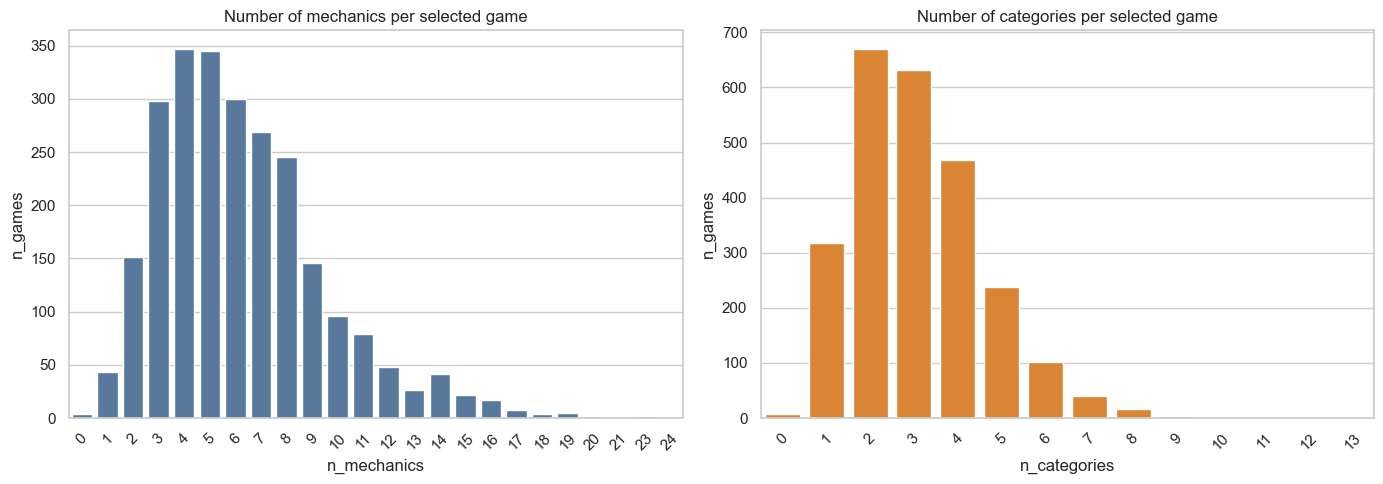

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=details_2500, x="n_mechanics", ax=axes[0], color="#4c78a8")
axes[0].set_title("Number of mechanics per selected game")
axes[0].set_xlabel("n_mechanics")
axes[0].set_ylabel("n_games")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=details_2500, x="n_categories", ax=axes[1], color="#f58518")
axes[1].set_title("Number of categories per selected game")
axes[1].set_xlabel("n_categories")
axes[1].set_ylabel("n_games")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

details_2500[["n_mechanics", "n_categories"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

## Per-User Status-Flag Composition

Reliable users qualify on `selected_game_overlap_count >= 10`, but overlap counts any status flag (own, prevowned, wishlist, want-to-play, ...). For the CS514 main analysis I plan to project ownership only. This section confirms how much of each user's selected-universe activity is `own=1` versus other statuses, by cohort.

If `frac_own` dominates, ownership-only projection is well supported. If wishlist/want-to-play are meaningful fractions, that's information worth carrying as an optional secondary edge layer later.

In [53]:
STATUS_COLS = ["own", "prevowned", "fortrade", "want", "wanttoplay", "wanttobuy", "wishlist", "preordered"]


def compute_user_status_composition(edge_paths, selected_ids, chunksize=500_000):
    selected_ids = set(map(int, selected_ids))
    usecols = ["username", "bgg_id"] + STATUS_COLS
    parts = []
    for edge_csv in edge_paths:
        for chunk in iter_edge_chunks(edge_csv, usecols=usecols, chunksize=chunksize):
            chunk = chunk[chunk["bgg_id"].isin(selected_ids)]
            if chunk.empty:
                continue
            for col in STATUS_COLS:
                chunk[col] = chunk[col].fillna(0).astype(int)
            chunk["edge_count"] = 1
            parts.append(chunk.groupby("username")[STATUS_COLS + ["edge_count"]].sum())
    if not parts:
        return pd.DataFrame()
    combined = pd.concat(parts).groupby(level=0).sum()
    return combined.reset_index()


status_comp = compute_user_status_composition([BASE_EDGE_CSV, EXP_EDGE_CSV], selected_ids)
status_comp = status_comp.merge(users[["username", "cohort"]], on="username", how="left")

for col in STATUS_COLS:
    status_comp[f"frac_{col}"] = status_comp[col] / status_comp["edge_count"].replace(0, np.nan)

print("users with at least one selected-edge:", len(status_comp))
status_comp[[f"frac_{c}" for c in STATUS_COLS]].describe(percentiles=[.1, .25, .5, .75, .9]).T

users with at least one selected-edge: 5653


,count,mean,std,min,10%,25%,50%,75%,90%,max
frac_own,5653.0,0.487959,0.293479,0.0,0.098362,0.242143,0.466019,0.740741,0.914286,1.000000
frac_prevowned,5653.0,0.101570,0.145124,0.0,0.000000,0.000000,0.035714,0.148810,0.306297,1.000000
frac_fortrade,5653.0,0.010343,0.029266,0.0,0.000000,0.000000,0.000000,0.006329,0.032334,0.722826
frac_want,5653.0,0.009904,0.044837,0.0,0.000000,0.000000,0.000000,0.000000,0.018868,0.781250
frac_wanttoplay,5653.0,0.049915,0.115464,0.0,0.000000,0.000000,0.000000,0.036320,0.171424,0.992740
frac_wanttobuy,5653.0,0.013220,0.046184,0.0,0.000000,0.000000,0.000000,0.005464,0.030105,0.707317
frac_wishlist,5653.0,0.051169,0.112229,0.0,0.000000,0.000000,0.006098,0.045584,0.149960,1.000000
frac_preordered,5653.0,0.004651,0.027132,0.0,0.000000,0.000000,0.000000,0.000000,0.008130,0.978723


status,own,prevowned,fortrade,want,wanttoplay,wanttobuy,wishlist,preordered
cohort,,,,,,,,
core_top69,0.491,0.097,0.010,0.010,0.050,0.014,0.052,0.005
expanded_diversity_01,0.460,0.146,0.013,0.011,0.053,0.007,0.039,0.005


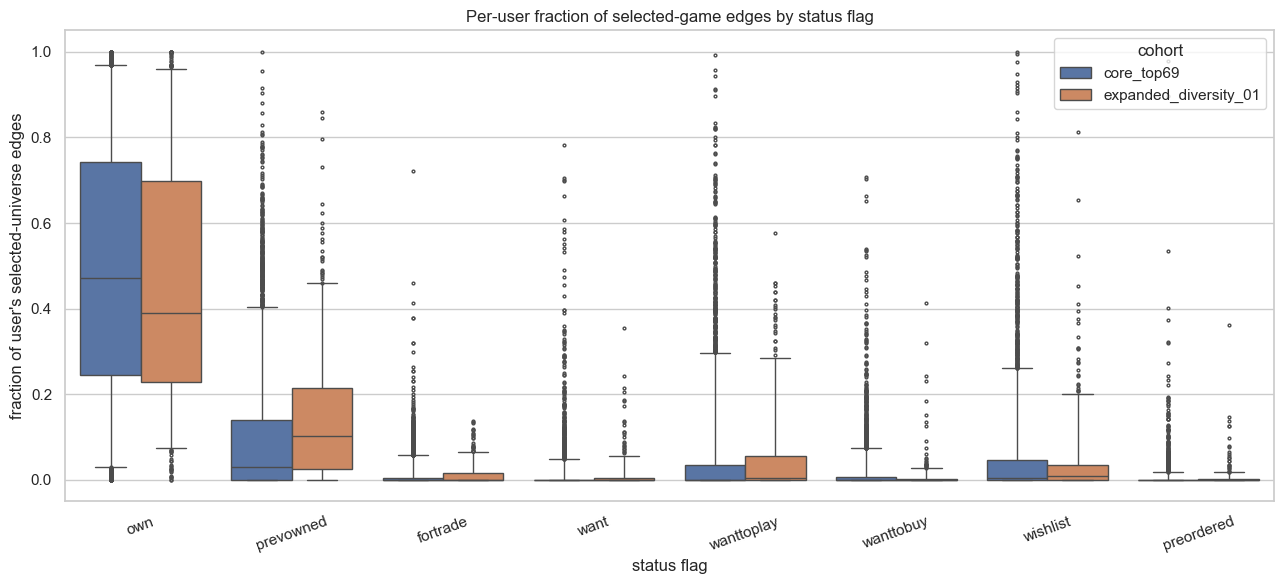

In [54]:
frac_cols = [f"frac_{c}" for c in STATUS_COLS]
melted = status_comp.melt(
    id_vars=["username", "cohort"],
    value_vars=frac_cols,
    var_name="status",
    value_name="fraction",
)
melted["status"] = melted["status"].str.replace("frac_", "", regex=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=melted,
    x="status",
    y="fraction",
    hue="cohort",
    ax=ax,
    fliersize=2,
    whis=(5, 95),
)
ax.set_title("Per-user fraction of selected-game edges by status flag")
ax.set_xlabel("status flag")
ax.set_ylabel("fraction of user's selected-universe edges")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

cohort_means = (
    melted.groupby(["cohort", "status"])["fraction"]
    .mean()
    .unstack("status")
    .reindex(columns=STATUS_COLS)
)
cohort_means.round(3)

## Bipartite Degree Distributions (Log-Log)

Both sides of the user-game bipartite graph viewed on log-log axes. A near-linear shape indicates a heavy-tailed degree distribution, which is the regime where the disparity backbone earns its keep — global thresholds would either under-prune the dense head or over-prune the long tail.

user side  — min 1 median 85 p99 561 max 1481
game side  — min 24 median 162 p99 1405 max 2275


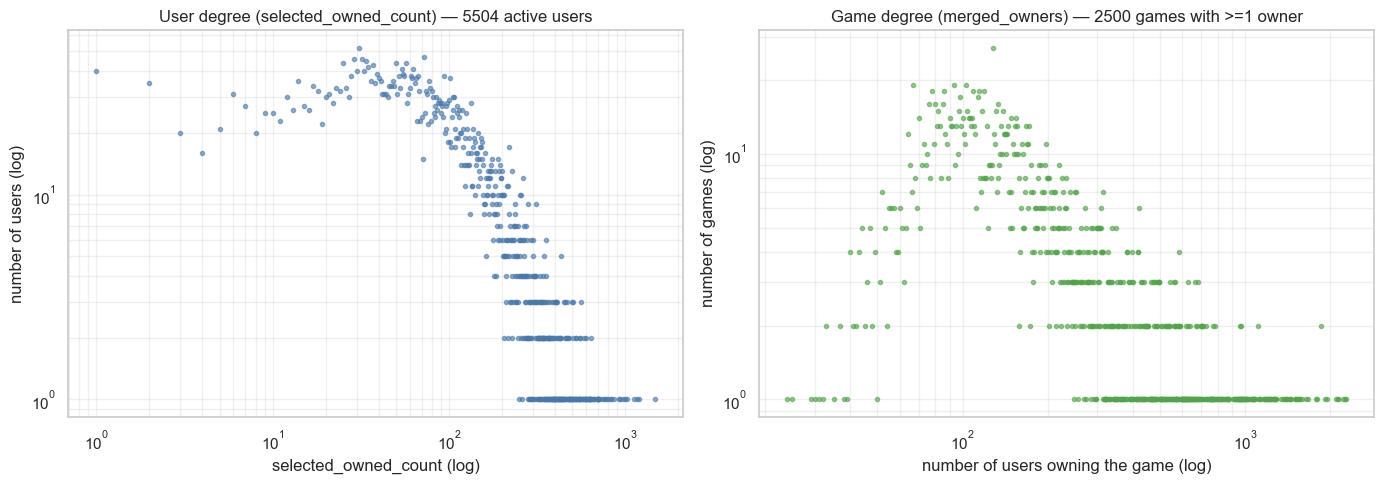

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_deg = users["selected_owned_count"].fillna(0).astype(int)
user_deg = user_deg[user_deg > 0]
user_deg_counts = user_deg.value_counts().sort_index()
axes[0].loglog(user_deg_counts.index, user_deg_counts.values, "o", markersize=3, alpha=0.6, color="#4c78a8")
axes[0].set_title(f"User degree (selected_owned_count) — {len(user_deg)} active users")
axes[0].set_xlabel("selected_owned_count (log)")
axes[0].set_ylabel("number of users (log)")
axes[0].grid(True, which="both", alpha=0.3)

game_deg = game_coverage["merged_owners"].astype(int)
game_deg = game_deg[game_deg > 0]
game_deg_counts = game_deg.value_counts().sort_index()
axes[1].loglog(game_deg_counts.index, game_deg_counts.values, "o", markersize=3, alpha=0.6, color="#54a24b")
axes[1].set_title(f"Game degree (merged_owners) — {len(game_deg)} games with >=1 owner")
axes[1].set_xlabel("number of users owning the game (log)")
axes[1].set_ylabel("number of games (log)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()

print("user side  — min", int(user_deg.min()), "median", int(user_deg.median()), "p99", int(user_deg.quantile(0.99)), "max", int(user_deg.max()))
print("game side  — min", int(game_deg.min()), "median", int(game_deg.median()), "p99", int(game_deg.quantile(0.99)), "max", int(game_deg.max()))

## Game Popularity vs BGG Rating and Weight

Cross-checks how the merged ownership signal correlates with BGG's curated `average_rating` and `average_weight`. If popularity correlates strongly with weight, communities may end up partly reflecting complexity tiers; if it correlates with rating, the projection picks up consensus-favorite clusters. Both possibilities matter for interpreting community labels later.

Spearman(merged_owners, average_rating) = 0.175
Spearman(merged_owners, average_weight) = 0.013


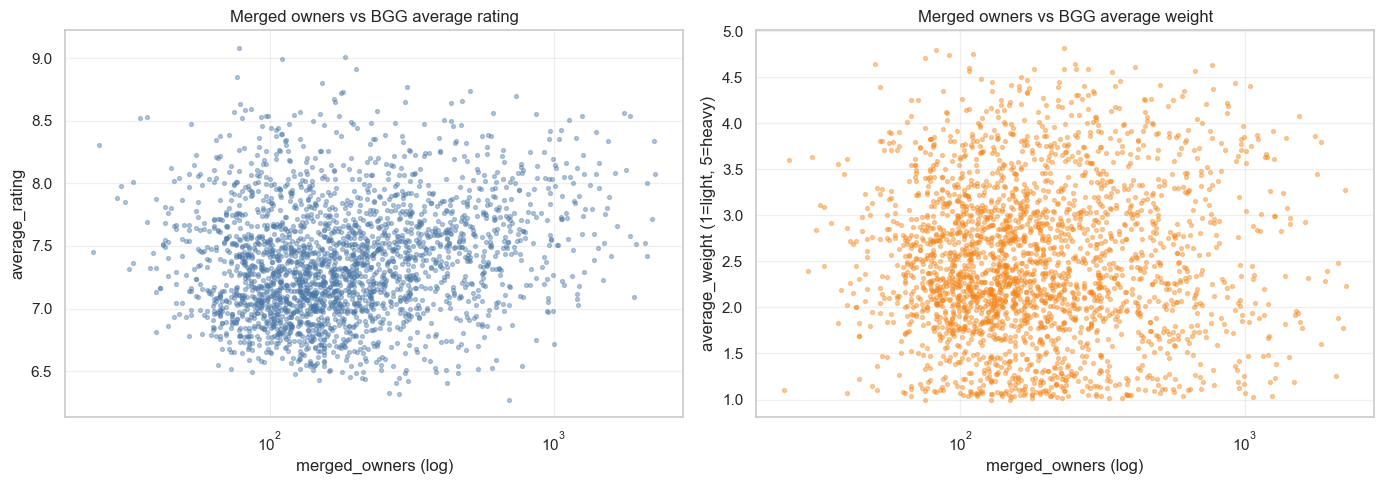

In [56]:
gc_rating = game_coverage[(game_coverage["merged_owners"] > 0) & game_coverage["average_rating"].notna()]
gc_weight = game_coverage[(game_coverage["merged_owners"] > 0) & game_coverage["average_weight"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(gc_rating["merged_owners"], gc_rating["average_rating"], s=8, alpha=0.4, color="#4c78a8")
axes[0].set_title("Merged owners vs BGG average rating")
axes[0].set_xlabel("merged_owners (log)")
axes[0].set_ylabel("average_rating")
axes[0].set_xscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(gc_weight["merged_owners"], gc_weight["average_weight"], s=8, alpha=0.4, color="#f58518")
axes[1].set_title("Merged owners vs BGG average weight")
axes[1].set_xlabel("merged_owners (log)")
axes[1].set_ylabel("average_weight (1=light, 5=heavy)")
axes[1].set_xscale("log")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

rho_rating = gc_rating[["merged_owners", "average_rating"]].corr(method="spearman").iloc[0, 1]
rho_weight = gc_weight[["merged_owners", "average_weight"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman(merged_owners, average_rating) = {rho_rating:.3f}")
print(f"Spearman(merged_owners, average_weight) = {rho_weight:.3f}")

## Full-2,500 Co-Ownership Weight Distribution

This is the most graph-relevant diagnostic. We build the user-game ownership incidence matrix once, then compute three pairwise weight distributions over all C(2500, 2) = 3,123,750 game pairs:

- **Raw co-owner count** — expected to be heavy-tailed and dominated by mainstream games.
- **Cosine similarity** — `co(i,j) / sqrt(owners(i) * owners(j))`. Corrects for game popularity but not for heavy collectors.
- **Newman RA / user-normalized weight** — each user u contributes `1/(d_u - 1)` per pair they co-own. Corrects per-pair for collection size; this is the proposed primary projection weight.

The shape of these distributions tells us how much room the disparity filter has to work with. If the bulk of weights cluster near zero with a long thin tail, the filter will retain a clean backbone. If the distribution is bimodal or has many high-weight ties, parameter tuning will be more delicate.

In [57]:
def build_user_game_incidence(users_df, edge_paths, selected_ids, chunksize=500_000):
    """Returns (A, user_index, game_index) where A is a float32 (users x games) ownership-only matrix."""
    user_index = {u: i for i, u in enumerate(users_df["username"].astype(str).tolist())}
    game_index = {int(g): i for i, g in enumerate(sorted(int(x) for x in selected_ids))}
    A = np.zeros((len(user_index), len(game_index)), dtype=np.float32)
    for edge_csv in edge_paths:
        print("streaming", edge_csv.name)
        for chunk in pd.read_csv(edge_csv, usecols=["username", "bgg_id", "own"], chunksize=chunksize, low_memory=False):
            chunk = chunk[chunk["bgg_id"].isin(set(game_index.keys()))]
            chunk = chunk[chunk["own"].fillna(0).astype(int) == 1]
            if chunk.empty:
                continue
            for username, gid in zip(chunk["username"].astype(str), chunk["bgg_id"].astype(int)):
                ui = user_index.get(username)
                if ui is None:
                    continue
                A[ui, game_index[gid]] = 1.0
    return A, user_index, game_index


A, user_index, game_index = build_user_game_incidence(users, [BASE_EDGE_CSV, EXP_EDGE_CSV], selected_ids)
n_users, n_games = A.shape
d_u = A.sum(axis=1)
g_owners = A.sum(axis=0)

active_users = int((d_u >= 2).sum())
active_games = int((g_owners >= 1).sum())
print(f"incidence matrix shape: {A.shape}")
print(f"users with selected_owned_count >= 2 (projection-active): {active_users}")
print(f"games with at least one owner: {active_games}")
print(f"non-zero ownership cells: {int(A.sum())}")

streaming reliable_user_collection_edges.csv
streaming reliable_user_collection_edges.csv
incidence matrix shape: (5653, 2500)
users with selected_owned_count >= 2 (projection-active): 5463
games with at least one owner: 2500
non-zero ownership cells: 639881


In [58]:
co_full = (A.T @ A).astype(np.float32)
np.fill_diagonal(co_full, 0)

denom = np.sqrt(np.outer(g_owners, g_owners))
denom[denom == 0] = 1.0
cosine_full = (co_full / denom).astype(np.float32)
np.fill_diagonal(cosine_full, 0)

ra_user_weight = np.where(d_u >= 2, 1.0 / np.maximum(d_u - 1, 1.0), 0.0).astype(np.float32)
A_w = A * ra_user_weight[:, np.newaxis]
ra_full = (A.T @ A_w).astype(np.float32)
np.fill_diagonal(ra_full, 0)

iu = np.triu_indices(n_games, k=1)
co_vals = co_full[iu]
cos_vals = cosine_full[iu]
ra_vals = ra_full[iu]

total_pairs = co_vals.size
nz_co = int((co_vals > 0).sum())
nz_cos = int((cos_vals > 0).sum())
nz_ra = int((ra_vals > 0).sum())
print(f"total upper-triangle pairs: {total_pairs:,}")
print(f"non-zero raw co-owner pairs: {nz_co:,} ({100*nz_co/total_pairs:.2f}%)")
print(f"non-zero cosine pairs:       {nz_cos:,} ({100*nz_cos/total_pairs:.2f}%)")
print(f"non-zero RA pairs:           {nz_ra:,} ({100*nz_ra/total_pairs:.2f}%)")

print()
print(f"co-owner: max {co_vals.max():.0f}  p99 {np.percentile(co_vals[co_vals>0], 99):.0f}  p50 {np.percentile(co_vals[co_vals>0], 50):.0f}")
print(f"cosine:   max {cos_vals.max():.4f}  p99 {np.percentile(cos_vals[cos_vals>0], 99):.4f}  p50 {np.percentile(cos_vals[cos_vals>0], 50):.4f}")
print(f"RA:       max {ra_vals.max():.4f}  p99 {np.percentile(ra_vals[ra_vals>0], 99):.4f}  p50 {np.percentile(ra_vals[ra_vals>0], 50):.4f}")

total upper-triangle pairs: 3,123,750
non-zero raw co-owner pairs: 3,079,584 (98.59%)
non-zero cosine pairs:       3,079,584 (98.59%)
non-zero RA pairs:           3,079,584 (98.59%)

co-owner: max 1290  p99 169  p50 13
cosine:   max 0.9163  p99 0.2621  p50 0.0760
RA:       max 12.4811  p99 0.9318  p50 0.0468


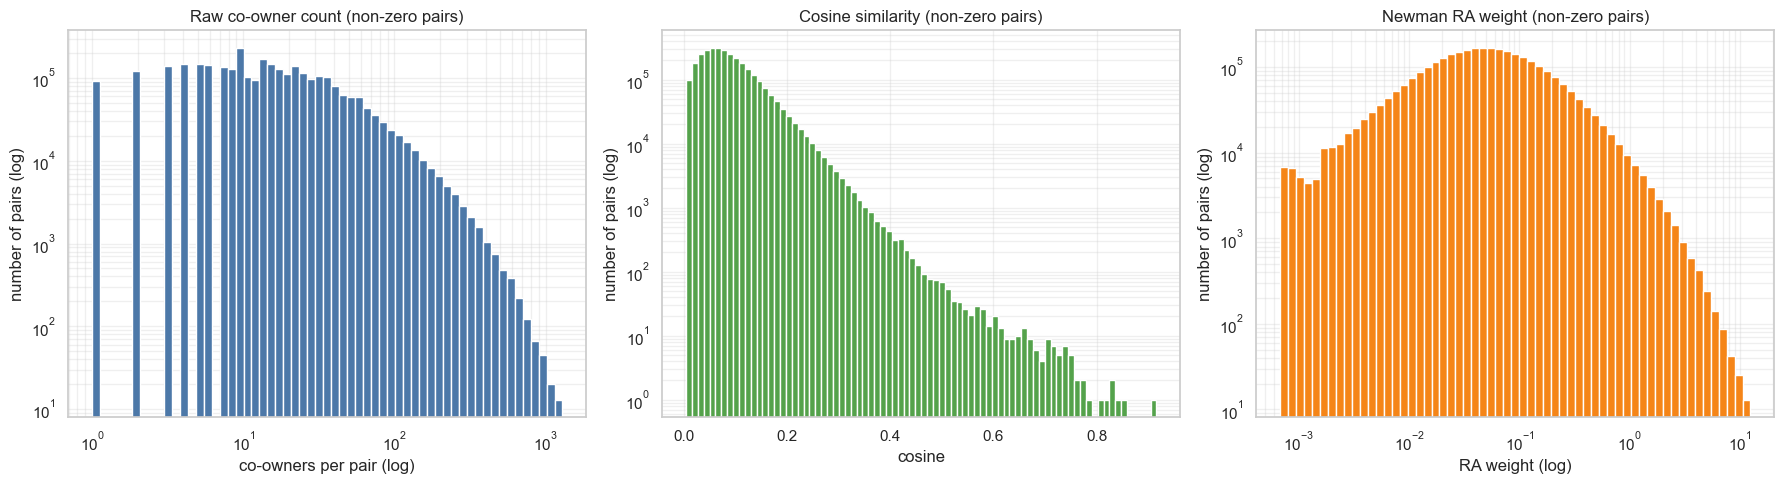

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

co_nz = co_vals[co_vals > 0]
axes[0].hist(co_nz, bins=np.logspace(0, np.log10(max(co_nz.max(), 2)), 60), color="#4c78a8")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Raw co-owner count (non-zero pairs)")
axes[0].set_xlabel("co-owners per pair (log)")
axes[0].set_ylabel("number of pairs (log)")
axes[0].grid(True, which="both", alpha=0.3)

cos_nz = cos_vals[cos_vals > 0]
axes[1].hist(cos_nz, bins=80, color="#54a24b")
axes[1].set_yscale("log")
axes[1].set_title("Cosine similarity (non-zero pairs)")
axes[1].set_xlabel("cosine")
axes[1].set_ylabel("number of pairs (log)")
axes[1].grid(True, which="both", alpha=0.3)

ra_nz = ra_vals[ra_vals > 0]
axes[2].hist(ra_nz, bins=np.logspace(np.log10(max(ra_nz.min(), 1e-6)), np.log10(ra_nz.max()), 60), color="#f58518")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_title("Newman RA weight (non-zero pairs)")
axes[2].set_xlabel("RA weight (log)")
axes[2].set_ylabel("number of pairs (log)")
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()

In [60]:
def top_pairs_from_matrix(M, game_idx_to_id, id_to_name, k=20):
    iu = np.triu_indices(M.shape[0], k=1)
    flat_vals = M[iu]
    order = np.argsort(flat_vals)[::-1][:k]
    rows = []
    for idx in order:
        i, j = iu[0][idx], iu[1][idx]
        rows.append({
            "game_i": id_to_name.get(game_idx_to_id[i], game_idx_to_id[i]),
            "game_j": id_to_name.get(game_idx_to_id[j], game_idx_to_id[j]),
            "weight": float(flat_vals[idx]),
        })
    return pd.DataFrame(rows)


game_idx_to_id = {i: gid for gid, i in game_index.items()}
id_to_name_full = dict(zip(details_2500["bgg_id"].astype(int), details_2500["name"]))

print("Top 20 pairs by RAW co-owner count:")
display(top_pairs_from_matrix(co_full, game_idx_to_id, id_to_name_full, k=20))

print("Top 20 pairs by COSINE:")
display(top_pairs_from_matrix(cosine_full, game_idx_to_id, id_to_name_full, k=20))

print("Top 20 pairs by NEWMAN RA:")
display(top_pairs_from_matrix(ra_full, game_idx_to_id, id_to_name_full, k=20))

Top 20 pairs by RAW co-owner count:


,game_i,game_j,weight
0,7 Wonders Duel,Azul,1290.0
1,Terraforming Mars,7 Wonders Duel,1266.0
2,Terraforming Mars,Wingspan,1262.0
3,Azul,Wingspan,1234.0
4,7 Wonders Duel,Wingspan,1221.0
5,Terraforming Mars,Ark Nova,1199.0
6,Terraforming Mars,Azul,1190.0
7,Codenames,Azul,1181.0
8,Patchwork,7 Wonders Duel,1172.0
9,7 Wonders Duel,Codenames,1162.0


Top 20 pairs by COSINE:


,game_i,game_j,weight
0,Mindbug: Beyond Evolution,Mindbug: Beyond Eternity,0.916258
1,Axis & Allies: Pacific 1940,Axis & Allies: Europe 1940,0.848943
2,Summoner Wars: Guild Dwarves vs Cave Goblins,Summoner Wars: Phoenix Elves vs Tundra Orcs,0.836886
3,Unmatched: Redemption Row,Unmatched: Hell's Kitchen,0.835467
4,Advanced Squad Leader: Starter Kit #2,Advanced Squad Leader: Starter Kit #3,0.833905
5,Chronicles of Crime: 1900,Chronicles of Crime: 2400,0.815116
6,Unmatched: Jurassic Park – InGen vs Raptors,Unmatched: Jurassic Park – Dr. Sattler vs. T. Rex,0.805231
7,Chronicles of Crime: 1400,Chronicles of Crime: 1900,0.783915
8,Smash Up: Science Fiction Double Feature,Smash Up: Monster Smash,0.777406
9,Kinfire Delve: Scorn's Stockade,Kinfire Delve: Callous' Lab,0.774984


Top 20 pairs by NEWMAN RA:


,game_i,game_j,weight
0,Terraforming Mars,7 Wonders Duel,12.481064
1,Terraforming Mars,Wingspan,12.222638
2,Catan,Carcassonne,12.113243
3,Azul,Wingspan,11.570811
4,7 Wonders Duel,Azul,11.539330
5,7 Wonders Duel,Wingspan,11.328247
6,Terraforming Mars,Ark Nova,11.317809
7,Terraforming Mars,Brass: Birmingham,11.156769
8,Terraforming Mars,Scythe,10.966400
9,Carcassonne,Pandemic,10.876069


## Useful Next EDA Extensions

Most of the original next-step list has now been folded into the notebook. Remaining optional extensions:

- Test disparity-filter alpha values on a smaller induced graph before scaling up to all 2,500 games.
- Mechanic-mechanic and category-category co-occurrence Jaccard heatmap (to support community interpretation).
- Per-game rating coverage across all 2,500 (currently rating EDA is limited to top-100).
- Year-published / decade analysis of selected games (only needed if temporal slicing enters the design).